<a href="https://colab.research.google.com/github/evtaindra/obe_standar_kurikulum/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import random
import itertools
import math
import matplotlib.pyplot as plt
import networkx as nx

random.seed(88)

nilai_awal = 50
nilai_akhir = 100

# Master table blueprint
records = [
    { 'variabel': 'ol', 'istilah': 'Profesi', 'size': 2 },
    { 'variabel': 'pl', 'istilah': 'Profil Lulusan', 'size': 3 },
    { 'variabel': 'cpl', 'istilah': 'Capaian Pembelajaran Lulusan', 'size': 7 },
    { 'variabel': 'bk', 'istilah': 'Bahan Kajian', 'size': 4 },
    { 'variabel': 'mk', 'istilah': 'Mata Kuliah', 'size': 9 },
    { 'variabel': 'cpmk', 'istilah': 'Capaian Pembelajaran Mata Kuliah', 'size': 30 },
    { 'variabel': 'scpmk', 'istilah': 'Sub-Capaian Pembelajaran Mata Kuliah', 'size': 65 },
]

# Create Master table
for record in records:
    singkatan = record['variabel'].upper()
    exec(record['variabel'] + ' = dict()')
    exec("data = { 'Kode " + singkatan + "': [], 'Nama " + singkatan + "': []}")
    for i in range(1, record['size'] + 1):
        exec("data['Kode " + singkatan + "'].append('" + singkatan + str(i).zfill(2) +  "')")
        exec("data['Nama " + singkatan + "'].append('" + record['istilah'] + " " + str(i).zfill(2) +  "')")
    exec(record['variabel'] + "_df = pd.DataFrame(data)")

# Create special IP table
ip_df = pd.DataFrame(
    {
        'Kode IP': ['IPL', 'IPT', 'IPP', 'IPW', 'IPO'],
        'Nama IP': ['Indikator Penilaian Lisan', 'Indikator Penilaian Tulisan', 'Indikator Penilaian Presensi', 'Indikator Penilaian Wawancara', 'Indikator Penilaian Observasi'],
    }
)

# Create percentages weight
weights = [10, 20, 30, 40, 50, 60, 70, 80, 90]
percentages = []
percentages.append([100])
for i in range(2, 5):
    combinations = list(itertools.combinations(weights, i))
    percentage = [combo for combo in combinations if sum(combo) == 100]
    percentages.append(percentage)

# Create generate random list
def generate_random_list(total, length):
    while True:
        result = [random.randint(1, math.ceil(length/total)) for _ in range(total)]
        if sum(result) == length:
            return result

# Calculate huruf
def calculate_huruf(akhir):
    if 80 <= akhir <= 100:
        return 'A'
    elif 70 <= akhir < 80:
        return 'B'
    elif 60 <= akhir < 70:
        return 'C'
    elif 50 <= akhir < 60:
        return 'D'
    else:
        return 'E'

# Calculate angka
def calculate_angka(huruf):
    if huruf == 'A':
        return 4
    elif huruf == 'B':
        return 3
    elif huruf == 'C':
        return 2
    elif huruf == 'D':
        return 1
    else:
        return 0

# Map SCPMK and IP
scpmk_ip_df = pd.DataFrame(columns=['Kode SCPMK', 'Kode IP', 'Bobot'])
for index, row in scpmk_df.iterrows():
    sampled_ip = ip_df.sample(n=random.randint(1, 3), replace=False)
    temp_df = pd.DataFrame({
        'Kode SCPMK': [row['Kode SCPMK']] * len(sampled_ip),
        'Kode IP': sampled_ip['Kode IP'].values,
        'Bobot': random.choice(percentages[len(sampled_ip)-1])
    })
    scpmk_ip_df = pd.concat([scpmk_ip_df, temp_df], ignore_index=True)
scpmk_weights_df = scpmk_ip_df.groupby('Kode SCPMK')['Bobot'].sum().reset_index().sort_values('Kode SCPMK')

# Map CPMK and SCPMK
cpmk_scpmk_df = pd.DataFrame(columns=['Kode CPMK', 'Kode SCPMK', 'Bobot'])
random_list = generate_random_list(cpmk_df.shape[0], scpmk_df.shape[0])
scpmk_codes = scpmk_df['Kode SCPMK'].to_list()
random.shuffle(scpmk_codes)
for index, row in cpmk_df.iterrows():
    scpmk_size = random_list[index]
    temp_df = pd.DataFrame({
        'Kode CPMK': [row['Kode CPMK']] * scpmk_size,
        'Kode SCPMK': [scpmk_codes.pop() for _ in range(scpmk_size)],
        'Bobot': random.choice(percentages[scpmk_size-1])
    })
    cpmk_scpmk_df = pd.concat([cpmk_scpmk_df, temp_df], ignore_index=True)
cpmk_weights_df = cpmk_scpmk_df.groupby('Kode CPMK')['Bobot'].sum().reset_index().sort_values('Kode CPMK')

# Map MK dan CPMK
mk_cpmk_df = pd.DataFrame(columns=['Kode MK', 'Kode CPMK', 'Bobot'])
random_list = generate_random_list(mk_df.shape[0], cpmk_df.shape[0])
cpmk_codes = cpmk_df['Kode CPMK'].to_list()
random.shuffle(cpmk_codes)
for index, row in mk_df.iterrows():
    cpmk_size = random_list[index]
    temp_df = pd.DataFrame({
        'Kode MK': [row['Kode MK']] * cpmk_size,
        'Kode CPMK': [cpmk_codes.pop() for _ in range(cpmk_size)],
        'Bobot': random.choice(percentages[cpmk_size-1])
    })
    mk_cpmk_df = pd.concat([mk_cpmk_df, temp_df], ignore_index=True)
mk_weights_df = mk_cpmk_df.groupby('Kode MK')['Bobot'].sum().reset_index().sort_values('Kode MK')

# Map CPL dan CPMK dari mk_cpmk_df
cpl_cpmk_df = pd.DataFrame(columns=['Kode CPL', 'Kode CPMK', 'Bobot'])
random_list = generate_random_list(cpl_df.shape[0], mk_cpmk_df.shape[0])
mk_cpmk_codes = mk_cpmk_df[['Kode CPMK', 'Bobot']].values.tolist()
random.shuffle(mk_cpmk_codes)
for index, row in cpl_df.iterrows():
    cpmk_size = random_list[index]
    cpmk_codes = []
    weights = []
    for _ in range(cpmk_size):
        cpmk_code, weight = mk_cpmk_codes.pop()
        cpmk_codes.append(cpmk_code)
        weights.append(weight)
    temp_df = pd.DataFrame({
        'Kode CPL': [row['Kode CPL']] * cpmk_size,
        'Kode CPMK': cpmk_codes,
        'Bobot': weights
    })
    cpl_cpmk_df = pd.concat([cpl_cpmk_df, temp_df], ignore_index=True)
cpl_weights_df = cpl_cpmk_df.groupby('Kode CPL')['Bobot'].sum().reset_index().sort_values('Kode CPL')

# Map PL dan CPL
pl_cpl_df = pd.DataFrame(columns=['Kode PL', 'Kode CPL', 'Bobot'])
random_list = generate_random_list(pl_df.shape[0], cpl_weights_df.shape[0])
cpl_weights_codes = cpl_weights_df.values.tolist()
random.shuffle(cpl_weights_codes)
for index, row in pl_df.iterrows():
    cpl_size = random_list[index]
    cpl_codes = []
    weights = []
    for _ in range(cpl_size):
        cpl_code, weight = cpl_weights_codes.pop()
        cpl_codes.append(cpl_code)
        weights.append(weight)
    temp_df = pd.DataFrame({
        'Kode PL': [row['Kode PL']] * cpl_size,
        'Kode CPL': cpl_codes,
        'Bobot': weights
    })
    pl_cpl_df = pd.concat([pl_cpl_df, temp_df], ignore_index=True)
pl_weights_df = pl_cpl_df.groupby('Kode PL')['Bobot'].sum().reset_index().sort_values('Kode PL')

# Map OL dan PL
ol_pl_df = pd.DataFrame(columns=['Kode OL', 'Kode PL', 'Bobot'])
random_list = generate_random_list(ol_df.shape[0], pl_weights_df.shape[0])
pl_weights_codes = pl_weights_df.values.tolist()
random.shuffle(pl_weights_codes)
for index, row in ol_df.iterrows():
    pl_size = random_list[index]
    pl_codes = []
    weights = []
    for _ in range(pl_size):
        pl_code, weight = pl_weights_codes.pop()
        pl_codes.append(pl_code)
        weights.append(weight)
    temp_df = pd.DataFrame({
        'Kode OL': [row['Kode OL']] * pl_size,
        'Kode PL': pl_codes,
        'Bobot': weights
    })
    ol_pl_df = pd.concat([ol_pl_df, temp_df], ignore_index=True)
ol_weights_df = ol_pl_df.groupby('Kode OL')['Bobot'].sum().reset_index().sort_values('Kode OL')

# Contoh Penilaian SCPMK
contoh_scpmk_ip_df = scpmk_ip_df.copy()
contoh_scpmk_ip_df['Nilai'] = [random.randint(nilai_awal, nilai_akhir) for _ in range(len(scpmk_ip_df))]
contoh_scpmk_ip_df['Akhir'] = contoh_scpmk_ip_df['Nilai'] * contoh_scpmk_ip_df['Bobot']/100
contoh_scpmk_weights_df = contoh_scpmk_ip_df.groupby('Kode SCPMK')['Akhir'].sum().reset_index().sort_values('Kode SCPMK')

# Contoh penilaian CPMK
contoh_cpmk_scpmk_df = pd.merge(cpmk_scpmk_df, contoh_scpmk_weights_df, on= 'Kode SCPMK', how= 'inner')
contoh_cpmk_scpmk_df.rename(columns={'Akhir': 'Nilai'}, inplace=True)
contoh_cpmk_scpmk_df['Akhir'] = contoh_cpmk_scpmk_df['Nilai'] * contoh_cpmk_scpmk_df['Bobot']/100
contoh_cpmk_weights_df = contoh_cpmk_scpmk_df.groupby('Kode CPMK')['Akhir'].sum().reset_index().sort_values('Kode CPMK')

# Contoh penilaian MK
contoh_mk_cpmk_df = pd.merge(mk_cpmk_df, contoh_cpmk_weights_df, on= 'Kode CPMK', how= 'inner')
contoh_mk_cpmk_df.rename(columns={'Akhir': 'Nilai'}, inplace=True)
contoh_mk_cpmk_df['Akhir'] = contoh_mk_cpmk_df['Nilai'] * contoh_mk_cpmk_df['Bobot']/100
contoh_mk_weights_df = contoh_mk_cpmk_df.groupby('Kode MK')['Akhir'].sum().reset_index().sort_values('Kode MK')
contoh_mk_lengkap_df = contoh_mk_weights_df.copy()
contoh_mk_lengkap_df['Huruf'] = contoh_mk_lengkap_df['Akhir'].apply(calculate_huruf)
contoh_mk_lengkap_df['Angka'] = contoh_mk_lengkap_df['Huruf'].apply(calculate_angka)
contoh_mk_lengkap_df['Kredit'] = np.random.choice([1, 2, 3], size=len(contoh_mk_lengkap_df))
contoh_mk_lengkap_df['Mutu'] = contoh_mk_lengkap_df['Angka'] * contoh_mk_lengkap_df['Kredit']
kredit = contoh_mk_lengkap_df['Kredit'].sum()
mutu = contoh_mk_lengkap_df['Mutu'].sum()
ipk = mutu / kredit

# Contoh penilaian CPL
contoh_cpl_cpmk_df = pd.merge(cpl_cpmk_df, contoh_cpmk_weights_df, on= 'Kode CPMK', how= 'inner')
contoh_cpl_cpmk_df.rename(columns={'Akhir': 'Nilai'}, inplace=True)
contoh_cpl_cpmk_df['Akhir'] = contoh_cpl_cpmk_df['Nilai'] * contoh_cpl_cpmk_df['Bobot']/100
contoh_cpl_weights_df = contoh_cpl_cpmk_df.groupby('Kode CPL')['Akhir'].sum().reset_index().sort_values('Kode CPL')
contoh_cpl_weights_persentase_df = contoh_cpl_cpmk_df.groupby('Kode CPL')[['Bobot', 'Akhir']].sum().reset_index().sort_values('Kode CPL')
contoh_cpl_weights_persentase_df['Persentase Capaian'] = contoh_cpl_weights_persentase_df['Akhir'] / contoh_cpl_weights_persentase_df['Bobot'] * 100

# Contoh penilaian PL
contoh_pl_cpl_df = pd.merge(pl_cpl_df, contoh_cpl_weights_df, on= 'Kode CPL', how= 'inner')
contoh_pl_weights_df = contoh_pl_cpl_df.groupby('Kode PL')['Akhir'].sum().reset_index().sort_values('Kode PL')
contoh_pl_weights_persentase_df = contoh_pl_cpl_df.groupby('Kode PL')[['Bobot', 'Akhir']].sum().reset_index().sort_values('Kode PL')
contoh_pl_weights_persentase_df['Persentase Capaian'] = contoh_pl_weights_persentase_df['Akhir'] / contoh_pl_weights_persentase_df['Bobot'] * 100

# Contoh penilaian OL
contoh_ol_pl_df = pd.merge(ol_pl_df, contoh_pl_weights_df, on= 'Kode PL', how= 'inner')
contoh_ol_weights_df = contoh_ol_pl_df.groupby('Kode OL')['Akhir'].sum().reset_index().sort_values('Kode OL')
contoh_ol_weights_persentase_df = contoh_ol_pl_df.groupby('Kode OL')[['Bobot', 'Akhir']].sum().reset_index().sort_values('Kode OL')
contoh_ol_weights_persentase_df['Persentase Capaian'] = contoh_ol_weights_persentase_df['Akhir'] / contoh_ol_weights_persentase_df['Bobot'] * 100

# Pengantar Kurikulum Outcome Based Education
Revisi 26 Mei 2025

![blooms-taxonomy-cpa](obe-comic-strip.jpg)

## Daftar Istilah
| No. | Istilah Bahasa Inggris | Singkatan | Istilah Bahasa Indonesia | Singkatan | Catatan |
| ----------- | ----------- | ----------- | ----------- | ----------- | ----------- |
| 1 | Outcome Based Education | OBE | Pendidikan Berbasis Hasil | PBH | Bukan apa yang diajarkan, tapi apa yang sudah dipelajari. |
| 2 | The Indonesian Qualification Framework | IQF | Kerangka Kualifikasi Nasional Indonesia | KKNI | Berasal dari pemerintah. |
| 3	| Indonesian National Work Competency Standards | INWCS | Standar Kompetensi Kerja Nasional Indonesia | SKKNI | Berasal dari pemerintah. |
| 4	| Occupational Maps | OM | Peta Okupasi | PO | Berasal dari pemerintah atau lembaga internasional. |
| 5	| Program Educational Objectives | PEO | Tujuan Pendidikan Program | TPP | Bukan VMTS keseluruhan Tridarma Program Studi, tapi hanya khusus VMTS Tridarma bagian Pengajaran. |
| 6	| Graduate Occupation | GO | Okupasi Lulusan | OL | Jenis/nama profesi yang sesuai dengan kekhasan program studi sebagai alternatif kemungkinan profesi yang nantinya dapat diambil oleh lulusan, minimum 1 maksimum 3. |
| 7	| Graduate Profiles | GP | Profil Lulusan | PL | Kemampuan/kompetensi yang akan dimiliki oleh lulusan sesuai dengan kebutuhan pengguna lulusan, minimum 4 maksimum 5. |
| 8	| Program Learning Outcomes | PLO | Capaian Pembelajaran Lulusan | CPL | Minimum 10 maksimum 15. |
| 9	| Subject Matters | SM | Bahan Kajian | BK | Disesuaikan dengan jumlah CPL. |
| 10 | Course  | C | Mata Kuliah | MK | Disesuaikan dengan jumlah CPL. |
| 11 | Course Learning Outcomes | CLO | Capaian Pembelajaran Mata Kuliah | CPMK | Disesuaikan dengan jumlah CPL. |
| 12 | Lesson Learning Outcomes | LLO | Sub-Capaian Pembelajaran Mata Kuliah | SCPMK | Turunan lebih rinci dari CPMK. |
| 13 | Assesment Indicators | AI | Indikator Penilaian | IP | Berupa penilaian Lisan, Tulisan, Presensi, Wawancara, atau Observasi. |
| 14 | Semester Course Learning Plan | SCLP | Rencana Pembelajaran Semester Mata Kuliah | RPSMK | Berisikan rencana setiap pertemuan pembelajaran. |
| 15 | Learning Topic | LT | Topik Pembelajaran | TP | Berisikan rencana rinci setiap pertemuan pembelajaran dan wajib berjumlah 16 topik.|
| 16 | Certificate of Competence | CC | Surat Keterangan Pendamping Ijazah | SKPI | Berisikan kompetensi dari CPL, PL, dan P dari alumni. |
| 17 | Academic Transcript | AT | Transkrip Akademik | TA | Berisikan MK yang diajarkan ke alumni. |
| 18 | Certificate Graduation | CG | Ijazah / Sertifikat Kelulusan | IS | Bukti lulus alumni. |

## Catatan OBE
1. OBE hanya merumuskan Tridarma Pengajaran;
2. Tridarma Penelitian dan Pengabdian Masyarakat bukan bagian dari OBE;
3. Bahan Kajian tidak sama dengan Mata Kuliah;
4. **Akumulasi bobot persentase CPL, PL, dan OL tidak sama dengan 100**;
5. **Akumulasi bobot persentase MK, CPMK, dan SCPMK sama dengan 100**;
6. CPL, CPMK, dan SCPMK terdiri dari Kata Kerja + Kata Benda + Konteks dengan kata kerja mengikuti tatanan pada Bloom Taksonomi;
   * Untuk tingkat Sarjana dan Profesi, mulai dari Applying;
   * Untuk tingkat Magister / Spesialis, mulai dari Applying, Analyzing, dan Evaluating;
   * Untuk tingkat Doktor, mulai dari Applying, Analyzing, Evaluating, dan Creating;
7. CPL wajib dipetakan dalam Sikap, Pengetahuan, Ketrampilan Umum, dan Ketrampilan Khusus;
8. **Yang paling penting dalam OBE adalah bagaimana cara menghitung CPL, PL, dan P melalui asesmen penilaian terstruktur**;
9. Kalimat **Bukan apa yang diajarkan** dalam OBE dituangkan dalam Transkrip Akademik;
10. Kalimat **tapi apa yang sudah dipelajari** dalam OBE dituangkan dalam Surat Keterangan Pendamping Ijazah;
11. Untuk setiap mata kuliah diwajibkan untuk membuat mindmap mata kuliah yang berisikan pemetaan CPMK, SCPMK, IP, dan TP.

## Komponen Dasar OBE
1. Topik Pembelajaran:
    - Teori Luar Jaringan;
    - Teori Dalam Jaringan;
    - Teori Hibrida;
    - Teori Mandiri;
    - Teori Eksternal;
    - Praktek Internal;
    - Praktek Eksternal;
3. Indikator Penilaian:
    - Penilaian Lisan;
    - Penilaian Tulisan;
    - Penilaian Presensi;
    - Penilaian Wawancara;
    - Penilaian Observasi.

## Beda CPL dan CPMK
1. Level Kognitif Bloom: REMEMBERING -> UNDERSTANDING -> APPLYING -> ANALYZING -> EVALUATING -> CREATING;
2. CPL disusun dengan berdasarkan hasil akhirnya pada tingkatan kognitif, seperti contoh level Sarjana, semua CPL sekitar 80% pasti berada pada level kognitif APPLYING, dan mungkin sekitar 20% bisa sampai sampai ANALYZING, EVALUATING, ataupun CREATING;
3. Untuk level Sarjana, CPL tidak boleh mengandung hanya sampai REMEMBERING atau UNDERSTANDING;
4. Untuk level Magister, 80% CPL harus banyak mengandung ANALYZING dan EVALUATING dan tidak boleh mengandung APPLYING;
5. Untuk level Doktor, 80% CPL harus banyak mengandung CREATING;
6. Sedangkan CPMK merupakan riwayat pembelajaran pada mata kuliah, sehingga CPMK boleh mulai dari kognitif REMEMBERING sampai kepada APPLYING;
7. Level kognitif CPMK tidak boleh melebihi CPL, seperti contoh CPL hanya sampai APPLYING, tapi ada turunan CPMK nya yang sampai ke CREATING.

## Bloom's Taxonomy
![blooms-taxonomy-cpa](blooms-taxonomy-cpa.jpg)

![blooms-taxonomy-cognitive](blooms-taxonomy-cognitive.jpg)

## Contoh Asesmen Penilaian
![asesmen-penilaian](asesmen-penilaian.jpg)

# Tahapan Penyusunan Kurikulum OBE di UNPRI

## Diagram OBE
![Kurikulum OBE](Kurikulum%20OBE.jpg)

Tahapan Penyusunan Kurikulum OBE di UNPRI:
1. Menyusun OL (6) -> PL (5) -> CPL (4) -> BK (Atas ke Tengah);
2. Menyusun BK -> MK (4) -> CPMK (3) -> SCPMK (2) -> IP (1) -> Pertemuan (Tengah ke Bawah);
3. Menggabungkan tahap 1 dan 2 dengan cara memetakan CPMK dan CPL.

Untuk memahami cara perhitungan OBE dapat dipelajari dengan cara mengikuti Bottom Up sebagai berikut:
* Level 0 - Topik Pembelajaran (TP)
* Level 1 - Indikator Penilaian (IP)
* Level 2 - Sub-Capaian Pembelajaran Mata Kuliah (SCPMK)
* Level 3 - Capaian Pembelajaran Mata Kuliah (CPMK)
* Level 4 - Mata Kuliah (MK)
* Level 4 - Capaian Pembelajaran Lulusan (CPL)
* Level 5 - Profil Lulusan (PL)
* Level 6 - Okupasi Lulusan (OL)

Untuk setiap komponen level OBE perlu disiapkan tiga proses dan peran, yaitu:
1. Definisi - diisi oleh Pusat Studi Akademik;
2. Pemetaan - diisi oleh Program Studi;
3. Bobot - diisi oleh Program Studi.

## Tahap 1 Penyusunan Kurikulum OBE
1. Okupasi Lulusan mengacu kepada rujukan SKKNI/Peta Okupasi;
2. Profil Lulusan mengacu kepada rujukan SKKNI/Peta Okupasi;
3. Capaian Pembelajaran Lulusan mengacu kepada:
    1. Permendikbud 53 tahun 2023, Pasal 7 sampai 9;
    2. Pertanyaan pada Panduan KPT 2024, halaman 33 sampai 38;
    3. Dari asosisasi/kolegium;
    4. Internasional;
4. Dasar pengisian:
    1. Definisi (PSA) dalam tiga bahasa, yaitu Indonesia, Inggris, dan Mandarin;
    2. Pemetaan (Program Studi).

Untuk menyusun Tahap 1 yang baik dapat menggunakan teknik bottom-up, yaitu:
1. Mengumpulkan seluruh mata kuliah program studi;
2. Untuk setiap mata kuliah, tentukan CPL dari mata kuliah tersebut;
3. Kumpulkan seluruh CPL yang sudah diekstrak dari mata kuliah;
4. Perkcil jumlah CPL menjadi sekitar 10 sampai 20 CPL dengan melakukan penyaringan kesamaan CPL untuk digabung menjadi satu;
5. Kelompokan setiap CPL menjadi PL;
6. Kelompokan setiap PL menjadi OL;
7. Gambarkan relasi antara OL, PL, dan CPL dalam bentuk peta konsep (mind map).

![Tahapan Kurikulum OBE](Kurikulum%20OBE%20Tahap%201.jpg)


## Tahap 2 Penyusunan Kurikulum OBE
1. Untuk setiap Mata Kuliah (MK), kumpulkan seluruh Topik Pembelajaran (TP) dari topik 1 sampai 16;
2. Susun Sub-Capain Pembelajaran Mata Kuliah (SCPMK) dari setiap TP sehingga setiap TP wajib mempunyai SCPMK terkait;
3. Untuk setiap SCPMK yang sudah disusun, tentukan Indikator Penilaian (IP) masing - masing dalam bentuk IP Lisan, Tulisan, Presensi, Wawancara, atau Observasi;
4. Susun Capaian Pembelajaran Mata Kuliah (CPMK) berdasarkan SCPMK yang ada, dan disarankan berjumlah sekitar 3 sampai 5 CPMK untuk setiap MK;
5. Tentukan bobot persentase untuk setiap IP yang ada dalam satu SCPMK sehingga total akhir persentase harus berjumlah 100%;
6. Tentukan bobot persentase untuk setiap SCPMK yang ada dalam satu CPMK sehingga total akhir persentase harus berjumlah 100%;
7. Tentukan bobot persentase untuk setiap CPMK yang ada dalam satu MK sehingga total akhir persentase harus berjumlah 100%;
8. Gambarkan relasi antara MK, CPMK, SCPMK, dan IP dalam bentuk peta konsep (mind map).

![Tahapan Kurikulum OBE](Kurikulum%20OBE%20Tahap%202.jpg)

## Tahap 3 Penyusunan Kurikulum OBE
1. Mengumpulkan seluruh CPL dan seluruh CPMK yang sudah dibuat pada tahap 1 dan 2;
2. Melakukan pemetaan antara CPL dan CPMK;
3. Tidak perlu menentukan bobot persentase karena bobot akan dihitung secara otomatis oleh sistem.

![Tahapan Kurikulum OBE](Kurikulum%20OBE%20Tahap%203.jpg)

## Tautan Pendukung


[Permendikbudristek Nomor 53 Tahun 2023](https://www.dropbox.com/scl/fi/opvw1so48lboj0blhdmzl/1.-Permendikbudristekdikti-RI-Nomor-53-Tahun-2023.pdf?rlkey=xv1fzws2byuauaxnhlx0mf0gf&st=2jawp1yg&dl=0)

[Buku Panduan Kurikulum Pendidikan Tinggi 2024](https://www.dropbox.com/scl/fi/dqstxuoa3ux8vgzn9xs7n/Buku-Panduan-KPT-2024-Direktorat-Pembelajaran-dan-Kemahasiswaan.pdf?rlkey=6ksy1wlp7ucxzky0ktexebojn&st=iw4hp5e1&dl=0)

[Panduan Daftar Kata Domain Kognitif, Afektif, dan Psikomotor](https://www.dropbox.com/scl/fi/bzium88jwqjzl1nr7uw4v/2025-02-17-daftar-kata-domain-obe.pdf?rlkey=ux1j44324h0dxof1w3a54wohm&st=u32wf7p3&dl=0)

[Prihandoko - Konsep dan Implementasi Kurikulum OBE](https://www.dropbox.com/scl/fi/v6yflk5phcu41wxe7al5q/20-Okt-2024-Kurikulum-OBE-v2.pdf?rlkey=rjyvftj4313bewohp74kfpsl9&st=kbhmi3ea&dl=0)

[Deny Jollyta - Konsep Kurikulum OBE dan Penerapannya](https://www.dropbox.com/scl/fi/35cteqsadohc9d49cpzdn/2025-01-20-konsep-kurikulum-obe-dan-penerapannya.pdf?rlkey=m6nz6go84am7nt1nim9t51t5t&dl=0)

[Objective Builder Tool](https://cdl.ucf.edu/teach/resources/objective-builder-tool/)

[Aplikasi Online Mindmap Ayoa](https://www.ayoa.com/)

# PENYUSUNAN KURIKULUM OBE

## Level 0 - Topik Pembelajaran (TP)

Topik pembelajaran wajib berjumlah 16 topik dan jumlah kredit (SKS) dalam bentuk:
- Teori Luar Jaringan;
- Teori Dalam Jaringan;
- Teori Hibrida;
- Teori Mandiri;
- Teori Eksternal;
- Praktek Internal;
- Praktek Eksternal.

## Level 1 - Indikator Penilaian (IP)

In [ ]:
ip_df

,Kode IP,Nama IP
0,IPL,Indikator Penilaian Lisan
1,IPT,Indikator Penilaian Tulisan
2,IPP,Indikator Penilaian Presensi
3,IPW,Indikator Penilaian Wawancara
4,IPO,Indikator Penilaian Observasi


## Level 2 - Sub-Capaian Pembelajaran Mata Kuliah (SCMPK)

### 2.1 Definisi SCPMK

In [ ]:
scpmk_df

,Kode SCPMK,Nama SCPMK
0,SCPMK01,Sub-Capaian Pembelajaran Mata Kuliah 01
1,SCPMK02,Sub-Capaian Pembelajaran Mata Kuliah 02
2,SCPMK03,Sub-Capaian Pembelajaran Mata Kuliah 03
3,SCPMK04,Sub-Capaian Pembelajaran Mata Kuliah 04
4,SCPMK05,Sub-Capaian Pembelajaran Mata Kuliah 05
...,...,...
60,SCPMK61,Sub-Capaian Pembelajaran Mata Kuliah 61
61,SCPMK62,Sub-Capaian Pembelajaran Mata Kuliah 62
62,SCPMK63,Sub-Capaian Pembelajaran Mata Kuliah 63
63,SCPMK64,Sub-Capaian Pembelajaran Mata Kuliah 64


### 2.2 Pemetaan SCMPK dan IP

In [ ]:
scpmk_ip_df

,Kode SCPMK,Kode IP,Bobot
0,SCPMK01,IPO,20
1,SCPMK01,IPP,80
2,SCPMK02,IPO,20
3,SCPMK02,IPL,80
4,SCPMK03,IPT,10
...,...,...,...
123,SCPMK63,IPL,100
124,SCPMK64,IPO,100
125,SCPMK65,IPT,20
126,SCPMK65,IPO,30


### 2.3 Bobot SCPMK

In [ ]:
scpmk_weights_df

,Kode SCPMK,Bobot
0,SCPMK01,100
1,SCPMK02,100
2,SCPMK03,100
3,SCPMK04,100
4,SCPMK05,100
...,...,...
60,SCPMK61,100
61,SCPMK62,100
62,SCPMK63,100
63,SCPMK64,100


## Level 3 - Capaian Pembelajaran Mata Kuliah (CPMK)

### 3.1 Definisi CPMK

In [ ]:
cpmk_df

,Kode CPMK,Nama CPMK
0,CPMK01,Capaian Pembelajaran Mata Kuliah 01
1,CPMK02,Capaian Pembelajaran Mata Kuliah 02
2,CPMK03,Capaian Pembelajaran Mata Kuliah 03
3,CPMK04,Capaian Pembelajaran Mata Kuliah 04
4,CPMK05,Capaian Pembelajaran Mata Kuliah 05
5,CPMK06,Capaian Pembelajaran Mata Kuliah 06
6,CPMK07,Capaian Pembelajaran Mata Kuliah 07
7,CPMK08,Capaian Pembelajaran Mata Kuliah 08
8,CPMK09,Capaian Pembelajaran Mata Kuliah 09
9,CPMK10,Capaian Pembelajaran Mata Kuliah 10


### 3.2 Pemetaan CPMK dan SCMPK

In [ ]:
cpmk_scpmk_df

,Kode CPMK,Kode SCPMK,Bobot
0,CPMK01,SCPMK37,100
1,CPMK02,SCPMK60,10
2,CPMK02,SCPMK45,40
3,CPMK02,SCPMK27,50
4,CPMK03,SCPMK46,10
...,...,...,...
60,CPMK28,SCPMK49,100
61,CPMK29,SCPMK13,20
62,CPMK29,SCPMK50,30
63,CPMK29,SCPMK23,50


### 3.3 Bobot CPMK

In [ ]:
cpmk_weights_df

,Kode CPMK,Bobot
0,CPMK01,100
1,CPMK02,100
2,CPMK03,100
3,CPMK04,100
4,CPMK05,100
5,CPMK06,100
6,CPMK07,100
7,CPMK08,100
8,CPMK09,100
9,CPMK10,100


## Level 4 - Mata Kuliah (MK)

### 4.1 Definisi MK

In [ ]:
mk_df

,Kode MK,Nama MK
0,MK01,Mata Kuliah 01
1,MK02,Mata Kuliah 02
2,MK03,Mata Kuliah 03
3,MK04,Mata Kuliah 04
4,MK05,Mata Kuliah 05
5,MK06,Mata Kuliah 06
6,MK07,Mata Kuliah 07
7,MK08,Mata Kuliah 08
8,MK09,Mata Kuliah 09


### 4.2 Pemetaan MK dan CPMK

In [ ]:
mk_cpmk_df

,Kode MK,Kode CPMK,Bobot
0,MK01,CPMK26,10
1,MK01,CPMK21,20
2,MK01,CPMK18,30
3,MK01,CPMK12,40
4,MK02,CPMK08,10
5,MK02,CPMK14,20
6,MK02,CPMK19,30
7,MK02,CPMK28,40
8,MK03,CPMK23,10
9,MK03,CPMK03,20


### 4.3 Bobot MK

In [ ]:
mk_weights_df

,Kode MK,Bobot
0,MK01,100
1,MK02,100
2,MK03,100
3,MK04,100
4,MK05,100
5,MK06,100
6,MK07,100
7,MK08,100
8,MK09,100


## Level 4 - Capaian Pembelajaran Lulusan (CPL)

### 4.1 Definisi CPL

In [ ]:
cpl_df

,Kode CPL,Nama CPL
0,CPL01,Capaian Pembelajaran Lulusan 01
1,CPL02,Capaian Pembelajaran Lulusan 02
2,CPL03,Capaian Pembelajaran Lulusan 03
3,CPL04,Capaian Pembelajaran Lulusan 04
4,CPL05,Capaian Pembelajaran Lulusan 05
5,CPL06,Capaian Pembelajaran Lulusan 06
6,CPL07,Capaian Pembelajaran Lulusan 07


### 4.2 Pemetaan CPL dan CPMK

Bobot dari CPMK diambil dari Bobot Pemetaan MK dan CPMK

In [ ]:
cpl_cpmk_df

,Kode CPL,Kode CPMK,Bobot
0,CPL01,CPMK17,10
1,CPL01,CPMK30,40
2,CPL01,CPMK15,40
3,CPL01,CPMK09,10
4,CPL02,CPMK18,30
5,CPL02,CPMK16,30
6,CPL02,CPMK08,10
7,CPL02,CPMK20,30
8,CPL03,CPMK21,20
9,CPL03,CPMK05,30


#### 4.2.1 Pemetaan MK dan CPMK diurut berdasarkan Kode CPMK

In [ ]:
mk_cpmk_df.sort_values(by="Kode CPMK")

,Kode MK,Kode CPMK,Bobot
13,MK04,CPMK01,40
28,MK09,CPMK02,20
9,MK03,CPMK03,20
18,MK06,CPMK04,70
25,MK08,CPMK05,30
20,MK07,CPMK06,20
23,MK08,CPMK07,10
4,MK02,CPMK08,10
19,MK07,CPMK09,10
24,MK08,CPMK10,20


### 4.3 Bobot CPL

In [ ]:
cpl_weights_df

,Kode CPL,Bobot
0,CPL01,100
1,CPL02,100
2,CPL03,90
3,CPL04,210
4,CPL05,150
5,CPL06,150
6,CPL07,100


## Level 5 - Profil Lulusan (PL)

### 5.1 Definisi PL

In [ ]:
pl_df

,Kode PL,Nama PL
0,PL01,Profil Lulusan 01
1,PL02,Profil Lulusan 02
2,PL03,Profil Lulusan 03


### 5.2 Pemetaan PL dan CPL

In [ ]:
pl_cpl_df

,Kode PL,Kode CPL,Bobot
0,PL01,CPL02,100
1,PL01,CPL03,90
2,PL02,CPL04,210
3,PL02,CPL07,100
4,PL02,CPL05,150
5,PL03,CPL06,150
6,PL03,CPL01,100


### 5.3 Bobot PL

In [ ]:
pl_weights_df

,Kode PL,Bobot
0,PL01,190
1,PL02,460
2,PL03,250


## Level 6 - Okupasi Lulusan (OL)

### 6.1 Definisi OL

In [ ]:
ol_df

,Kode OL,Nama OL
0,OL01,Profesi 01
1,OL02,Profesi 02


### 6.2 Pemetaan OL dan PL

In [ ]:
ol_pl_df

,Kode OL,Kode PL,Bobot
0,OL01,PL01,190
1,OL01,PL03,250
2,OL02,PL02,460


### 6.3 Bobot OL

In [ ]:
ol_weights_df

,Kode OL,Bobot
0,OL01,440
1,OL02,460


## CONTOH ASESMEN PENILAIAN

## Level 2 - Penilaian SCPMK

In [ ]:
contoh_scpmk_ip_df

,Kode SCPMK,Kode IP,Bobot,Nilai,Akhir
0,SCPMK01,IPO,20,67,13.4
1,SCPMK01,IPP,80,73,58.4
2,SCPMK02,IPO,20,50,10.0
3,SCPMK02,IPL,80,72,57.6
4,SCPMK03,IPT,10,100,10.0
...,...,...,...,...,...
123,SCPMK63,IPL,100,90,90.0
124,SCPMK64,IPO,100,100,100.0
125,SCPMK65,IPT,20,62,12.4
126,SCPMK65,IPO,30,62,18.6


### 2.1 Akumulasi Bobot SCPMK

In [ ]:
contoh_scpmk_weights_df

,Kode SCPMK,Akhir
0,SCPMK01,71.8
1,SCPMK02,67.6
2,SCPMK03,76.7
3,SCPMK04,68.7
4,SCPMK05,91.2
...,...,...
60,SCPMK61,59.0
61,SCPMK62,85.7
62,SCPMK63,90.0
63,SCPMK64,100.0


## Level 3 - Penilaian CPMK

In [ ]:
contoh_cpmk_scpmk_df

,Kode CPMK,Kode SCPMK,Bobot,Nilai,Akhir
0,CPMK01,SCPMK37,100,97.0,97.0
1,CPMK02,SCPMK60,10,74.5,7.45
2,CPMK02,SCPMK45,40,75.8,30.32
3,CPMK02,SCPMK27,50,56.7,28.35
4,CPMK03,SCPMK46,10,74.5,7.45
...,...,...,...,...,...
60,CPMK28,SCPMK49,100,70.2,70.2
61,CPMK29,SCPMK13,20,94.6,18.92
62,CPMK29,SCPMK50,30,93.0,27.9
63,CPMK29,SCPMK23,50,80.8,40.4


### 3.1 Akumulasi Bobot CPMK

In [ ]:
contoh_cpmk_weights_df

,Kode CPMK,Akhir
0,CPMK01,97.0
1,CPMK02,66.12
2,CPMK03,90.33
3,CPMK04,80.56
4,CPMK05,76.7
5,CPMK06,91.8
6,CPMK07,87.3
7,CPMK08,67.45
8,CPMK09,100.0
9,CPMK10,86.26


## Level 4 - Penilaian MK

In [ ]:
contoh_mk_cpmk_df

,Kode MK,Kode CPMK,Bobot,Nilai,Akhir
0,MK01,CPMK26,10,78.5,7.85
1,MK01,CPMK21,20,73.16,14.632
2,MK01,CPMK18,30,87.47,26.241
3,MK01,CPMK12,40,64.48,25.792
4,MK02,CPMK08,10,67.45,6.745
5,MK02,CPMK14,20,80.0,16.0
6,MK02,CPMK19,30,80.88,24.264
7,MK02,CPMK28,40,70.2,28.08
8,MK03,CPMK23,10,87.49,8.749
9,MK03,CPMK03,20,90.33,18.066


### 4.1 Akumulasi Bobot MK

In [ ]:
contoh_mk_weights_df

,Kode MK,Akhir
0,MK01,74.515
1,MK02,75.089
2,MK03,71.655
3,MK04,86.732
4,MK05,81.34
5,MK06,80.812
6,MK07,79.002
7,MK08,77.544
8,MK09,82.768


### 4.2 Indeks Prestasi Kumulatif

In [ ]:
contoh_mk_lengkap_df

,Kode MK,Akhir,Huruf,Angka,Kredit,Mutu
0,MK01,74.515,B,3,3,9
1,MK02,75.089,B,3,1,3
2,MK03,71.655,B,3,1,3
3,MK04,86.732,A,4,3,12
4,MK05,81.34,A,4,3,12
5,MK06,80.812,A,4,3,12
6,MK07,79.002,B,3,2,6
7,MK08,77.544,B,3,2,6
8,MK09,82.768,A,4,1,4


In [ ]:
print('Total Kredit              = ', kredit)
print('Total Mutu                = ', mutu)
print('Indeks Prestasi Kumulatif = ', ipk)

Total Kredit              =  19
Total Mutu                =  67
Indeks Prestasi Kumulatif =  3.526315789473684


## Level 4 - Penilaian CPL

In [ ]:
contoh_cpl_cpmk_df

,Kode CPL,Kode CPMK,Bobot,Nilai,Akhir
0,CPL01,CPMK17,10,84.9,8.49
1,CPL01,CPMK30,40,65.3,26.12
2,CPL01,CPMK15,40,71.38,28.552
3,CPL01,CPMK09,10,100.0,10.0
4,CPL02,CPMK18,30,87.47,26.241
5,CPL02,CPMK16,30,81.4,24.42
6,CPL02,CPMK08,10,67.45,6.745
7,CPL02,CPMK20,30,62.4,18.72
8,CPL03,CPMK21,20,73.16,14.632
9,CPL03,CPMK05,30,76.7,23.01


### 4.1 Akumulasi Bobot CPL

In [ ]:
contoh_cpl_weights_df

,Kode CPL,Akhir
0,CPL01,73.162
1,CPL02,76.126
2,CPL03,64.314
3,CPL04,169.508
4,CPL05,129.108
5,CPL06,112.202
6,CPL07,85.037


### 4.2 Persentase bobot CPL

In [ ]:
contoh_cpl_weights_persentase_df

,Kode CPL,Bobot,Akhir,Persentase Capaian
0,CPL01,100,73.162,73.162
1,CPL02,100,76.126,76.126
2,CPL03,90,64.314,71.46
3,CPL04,210,169.508,80.718095
4,CPL05,150,129.108,86.072
5,CPL06,150,112.202,74.801333
6,CPL07,100,85.037,85.037


## Level 5 - Penilaian PL

In [ ]:
contoh_pl_cpl_df

,Kode PL,Kode CPL,Bobot,Akhir
0,PL01,CPL02,100,76.126
1,PL01,CPL03,90,64.314
2,PL02,CPL04,210,169.508
3,PL02,CPL07,100,85.037
4,PL02,CPL05,150,129.108
5,PL03,CPL06,150,112.202
6,PL03,CPL01,100,73.162


### 5.1 Akumulasi Penilaian PL

In [ ]:
contoh_pl_weights_df

,Kode PL,Akhir
0,PL01,140.44
1,PL02,383.653
2,PL03,185.364


### 5.2 Persentase Penilaian PL

In [ ]:
contoh_pl_weights_persentase_df

,Kode PL,Bobot,Akhir,Persentase Capaian
0,PL01,190,140.44,73.915789
1,PL02,460,383.653,83.402826
2,PL03,250,185.364,74.1456


## Level 6 - Penilaian OL

In [ ]:
contoh_ol_pl_df

,Kode OL,Kode PL,Bobot,Akhir
0,OL01,PL01,190,140.44
1,OL01,PL03,250,185.364
2,OL02,PL02,460,383.653


### 6.1 Akumulasi Penilaian OL

In [ ]:
contoh_ol_weights_df

,Kode OL,Akhir
0,OL01,325.804
1,OL02,383.653


### 6.2 Persentase Penilaian OL

In [ ]:
contoh_ol_weights_persentase_df

,Kode OL,Bobot,Akhir,Persentase Capaian
0,OL01,440,325.804,74.046364
1,OL02,460,383.653,83.402826


## Rencana Pembelajaran Semester Mata Kuliah

### Daftar Istilah RPSMK
| Singkatan | Uraian |
| --------- | ----------- |
| TP | Topik Pembelajaran |
| TS | Topik Syarat Kelulusan |
| IP | Indikator Penilaian |
| SCPMK | Sub-Capaian Pembelajaran Mata Kuliah |
| CPMK | Capaian Pembelajaran Mata Kuliah |
| MK | Mata Kuliah |
| CPL | Capaian Pembelajaran Lulusan |

### Contoh Rencana Pembelajaran Semester Mata Kuliah

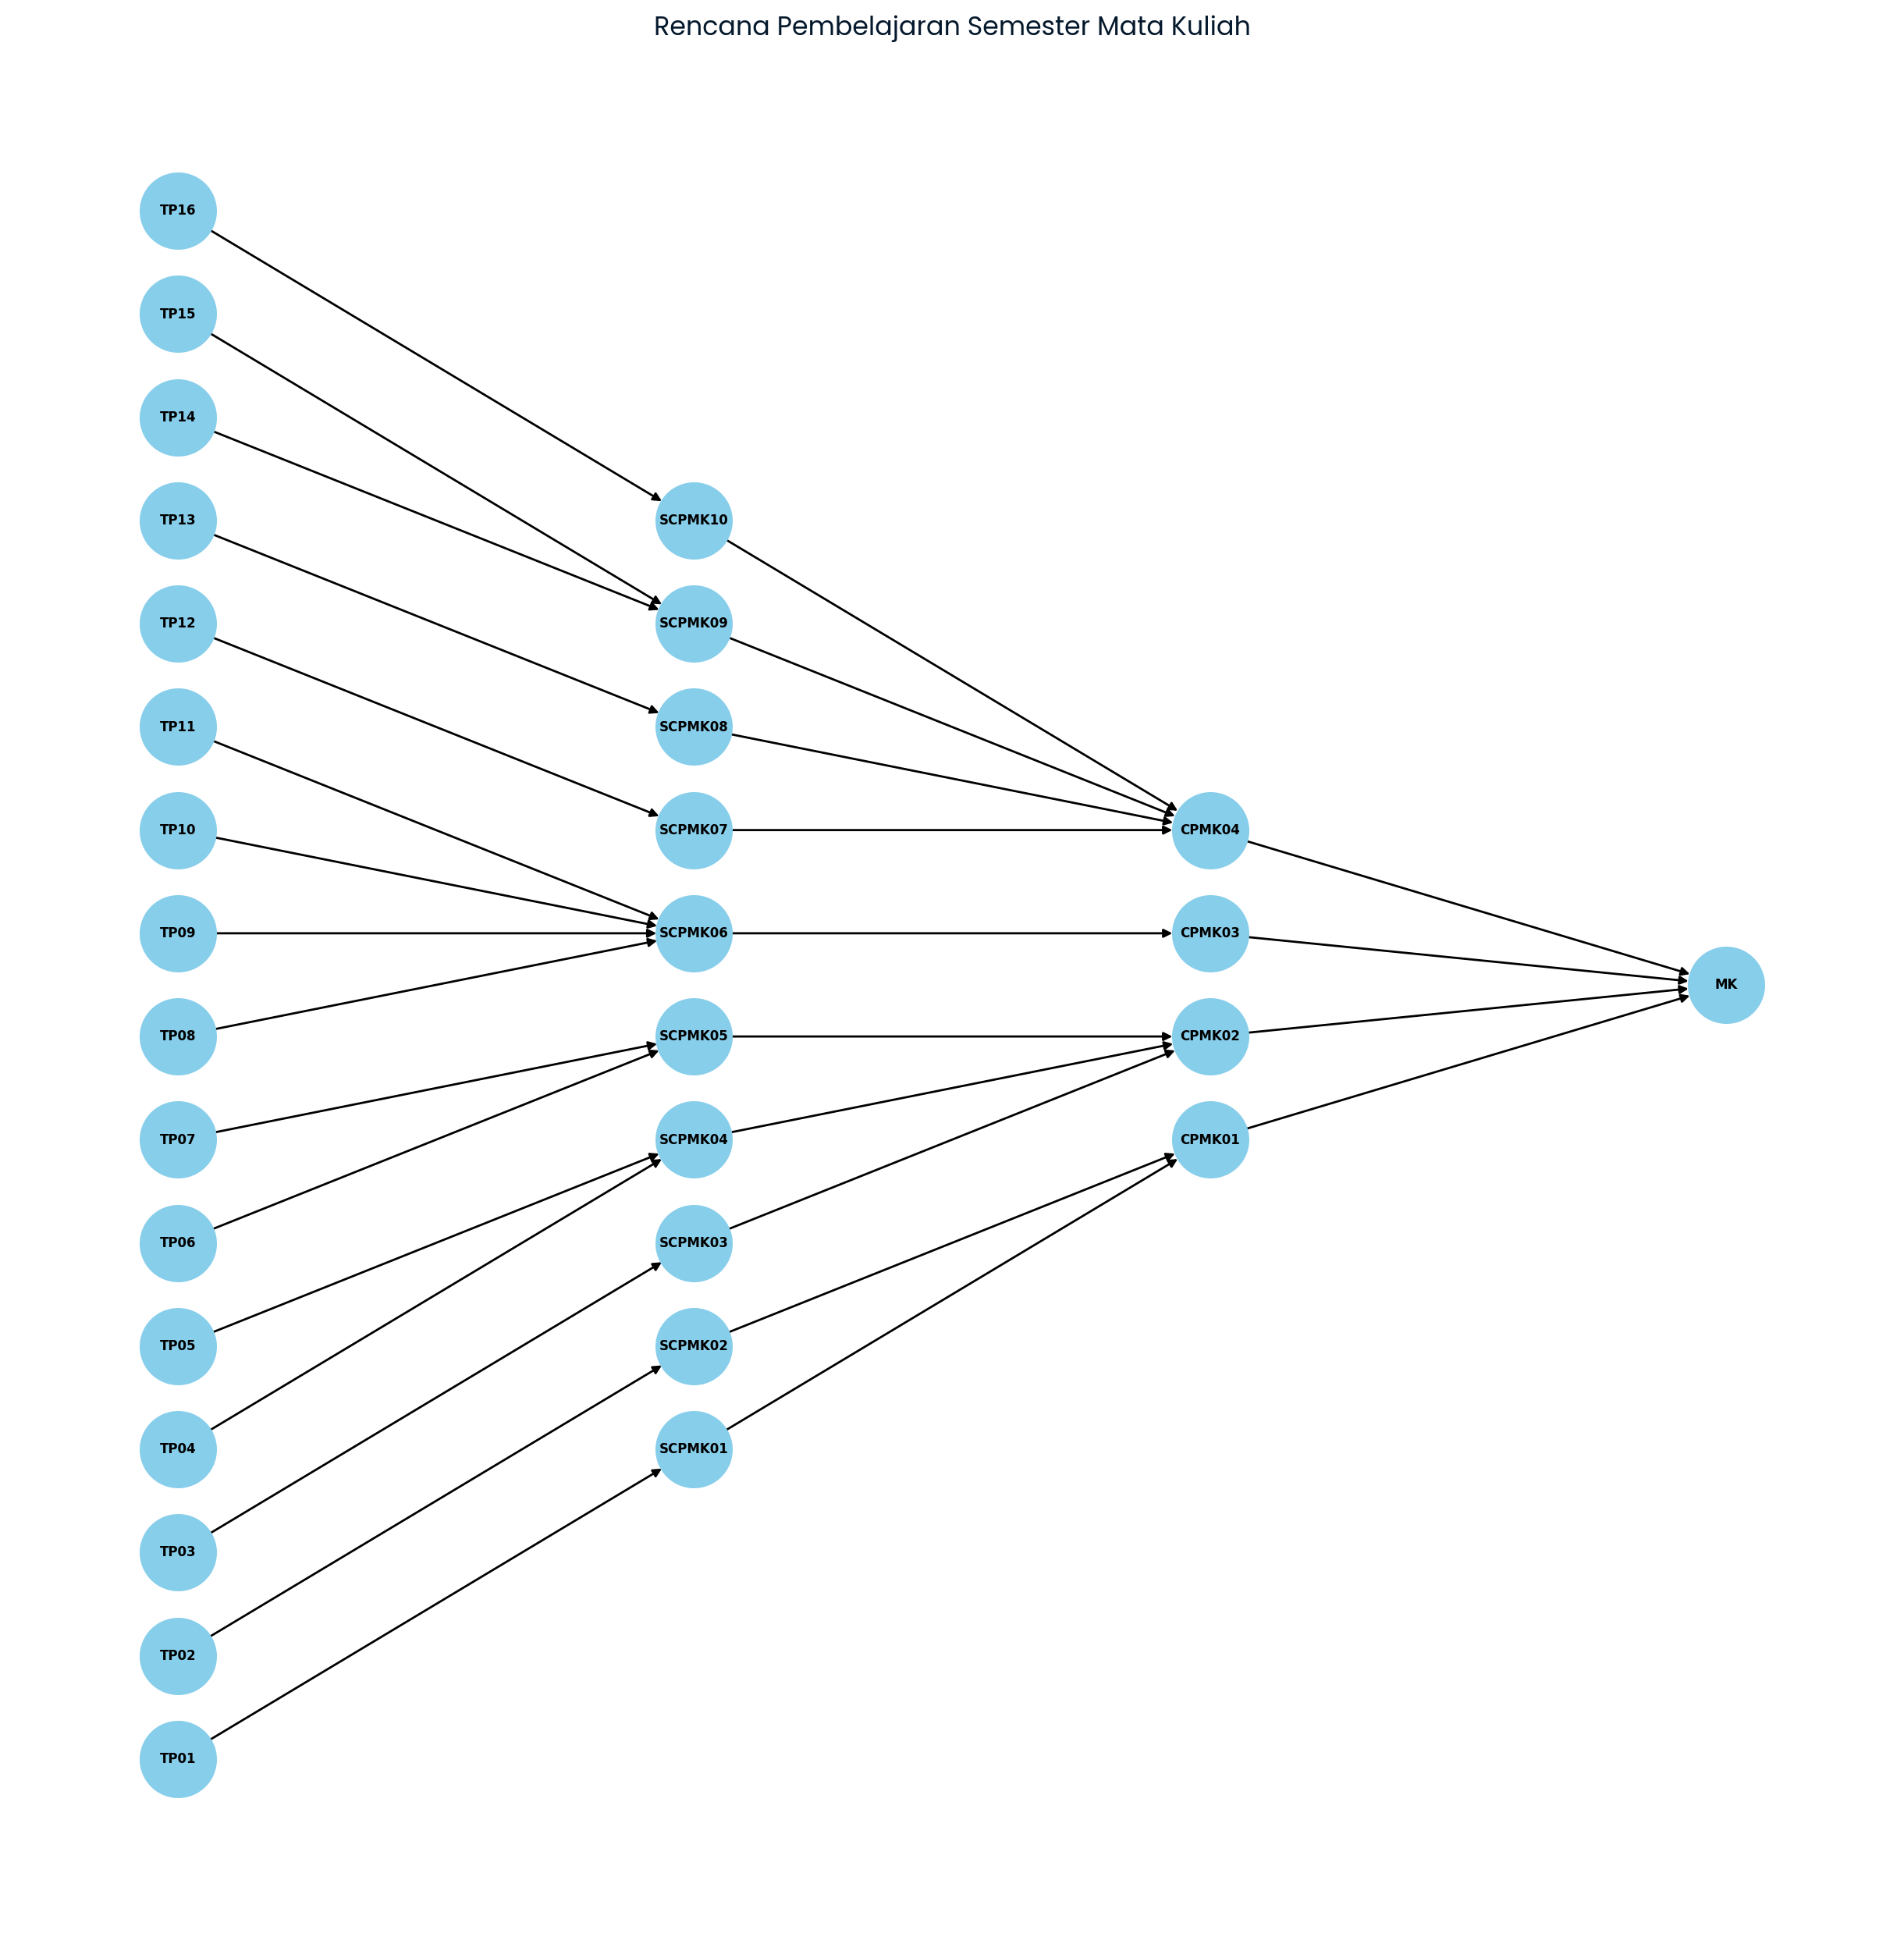

In [ ]:
nodes = {
    **{f'TP{str(i+1).zfill(2)}':     (0, 60 + i * 30) for i in range(0, 16)},
    **{f'SCPMK{str(i+1).zfill(2)}': (1, 150 + i * 30) for i in range(0, 10)},
    **{f'CPMK{str(i+1).zfill(2)}':  (2, 240 + i * 30) for i in range(0, 4)},
    'MK': (3, 285),
}

edges = [
    ('TP01', 'SCPMK01'),
    ('TP02', 'SCPMK02'),
    ('TP03', 'SCPMK03'),
    ('TP04', 'SCPMK04'),
    ('TP05', 'SCPMK04'),
    ('TP06', 'SCPMK05'),
    ('TP07', 'SCPMK05'),
    ('TP08', 'SCPMK06'),
    ('TP09', 'SCPMK06'),
    ('TP10', 'SCPMK06'),
    ('TP11', 'SCPMK06'),
    ('TP12', 'SCPMK07'),
    ('TP13', 'SCPMK08'),
    ('TP14', 'SCPMK09'),
    ('TP15', 'SCPMK09'),
    ('TP16', 'SCPMK10'),

    ('SCPMK01', 'CPMK01'),
    ('SCPMK02', 'CPMK01'),
    ('SCPMK03', 'CPMK02'),
    ('SCPMK04', 'CPMK02'),
    ('SCPMK05', 'CPMK02'),
    ('SCPMK06', 'CPMK03'),
    ('SCPMK07', 'CPMK04'),
    ('SCPMK08', 'CPMK04'),
    ('SCPMK09', 'CPMK04'),
    ('SCPMK10', 'CPMK04'),

    ('CPMK01','MK'),
    ('CPMK02','MK'),
    ('CPMK03','MK'),
    ('CPMK04','MK'),
]

G = nx.DiGraph()
G.add_nodes_from(nodes.keys())
G.add_edges_from(edges)

plt.figure(figsize=(12, 12))
nx.draw(G, pos=nodes, with_labels=True, node_size=1200, node_color="skyblue", font_size=6, font_weight="bold", arrowsize=8)
plt.title("Rencana Pembelajaran Semester Mata Kuliah")
plt.show()

### Contoh Asesmen Penilaian

OBE = Bukan apa yang diajarkan, tapi apa yang sudah dipelajari, **bila lupa bukan salah institusi**.

#### Contoh Pertama - Model OBE Yang Baik

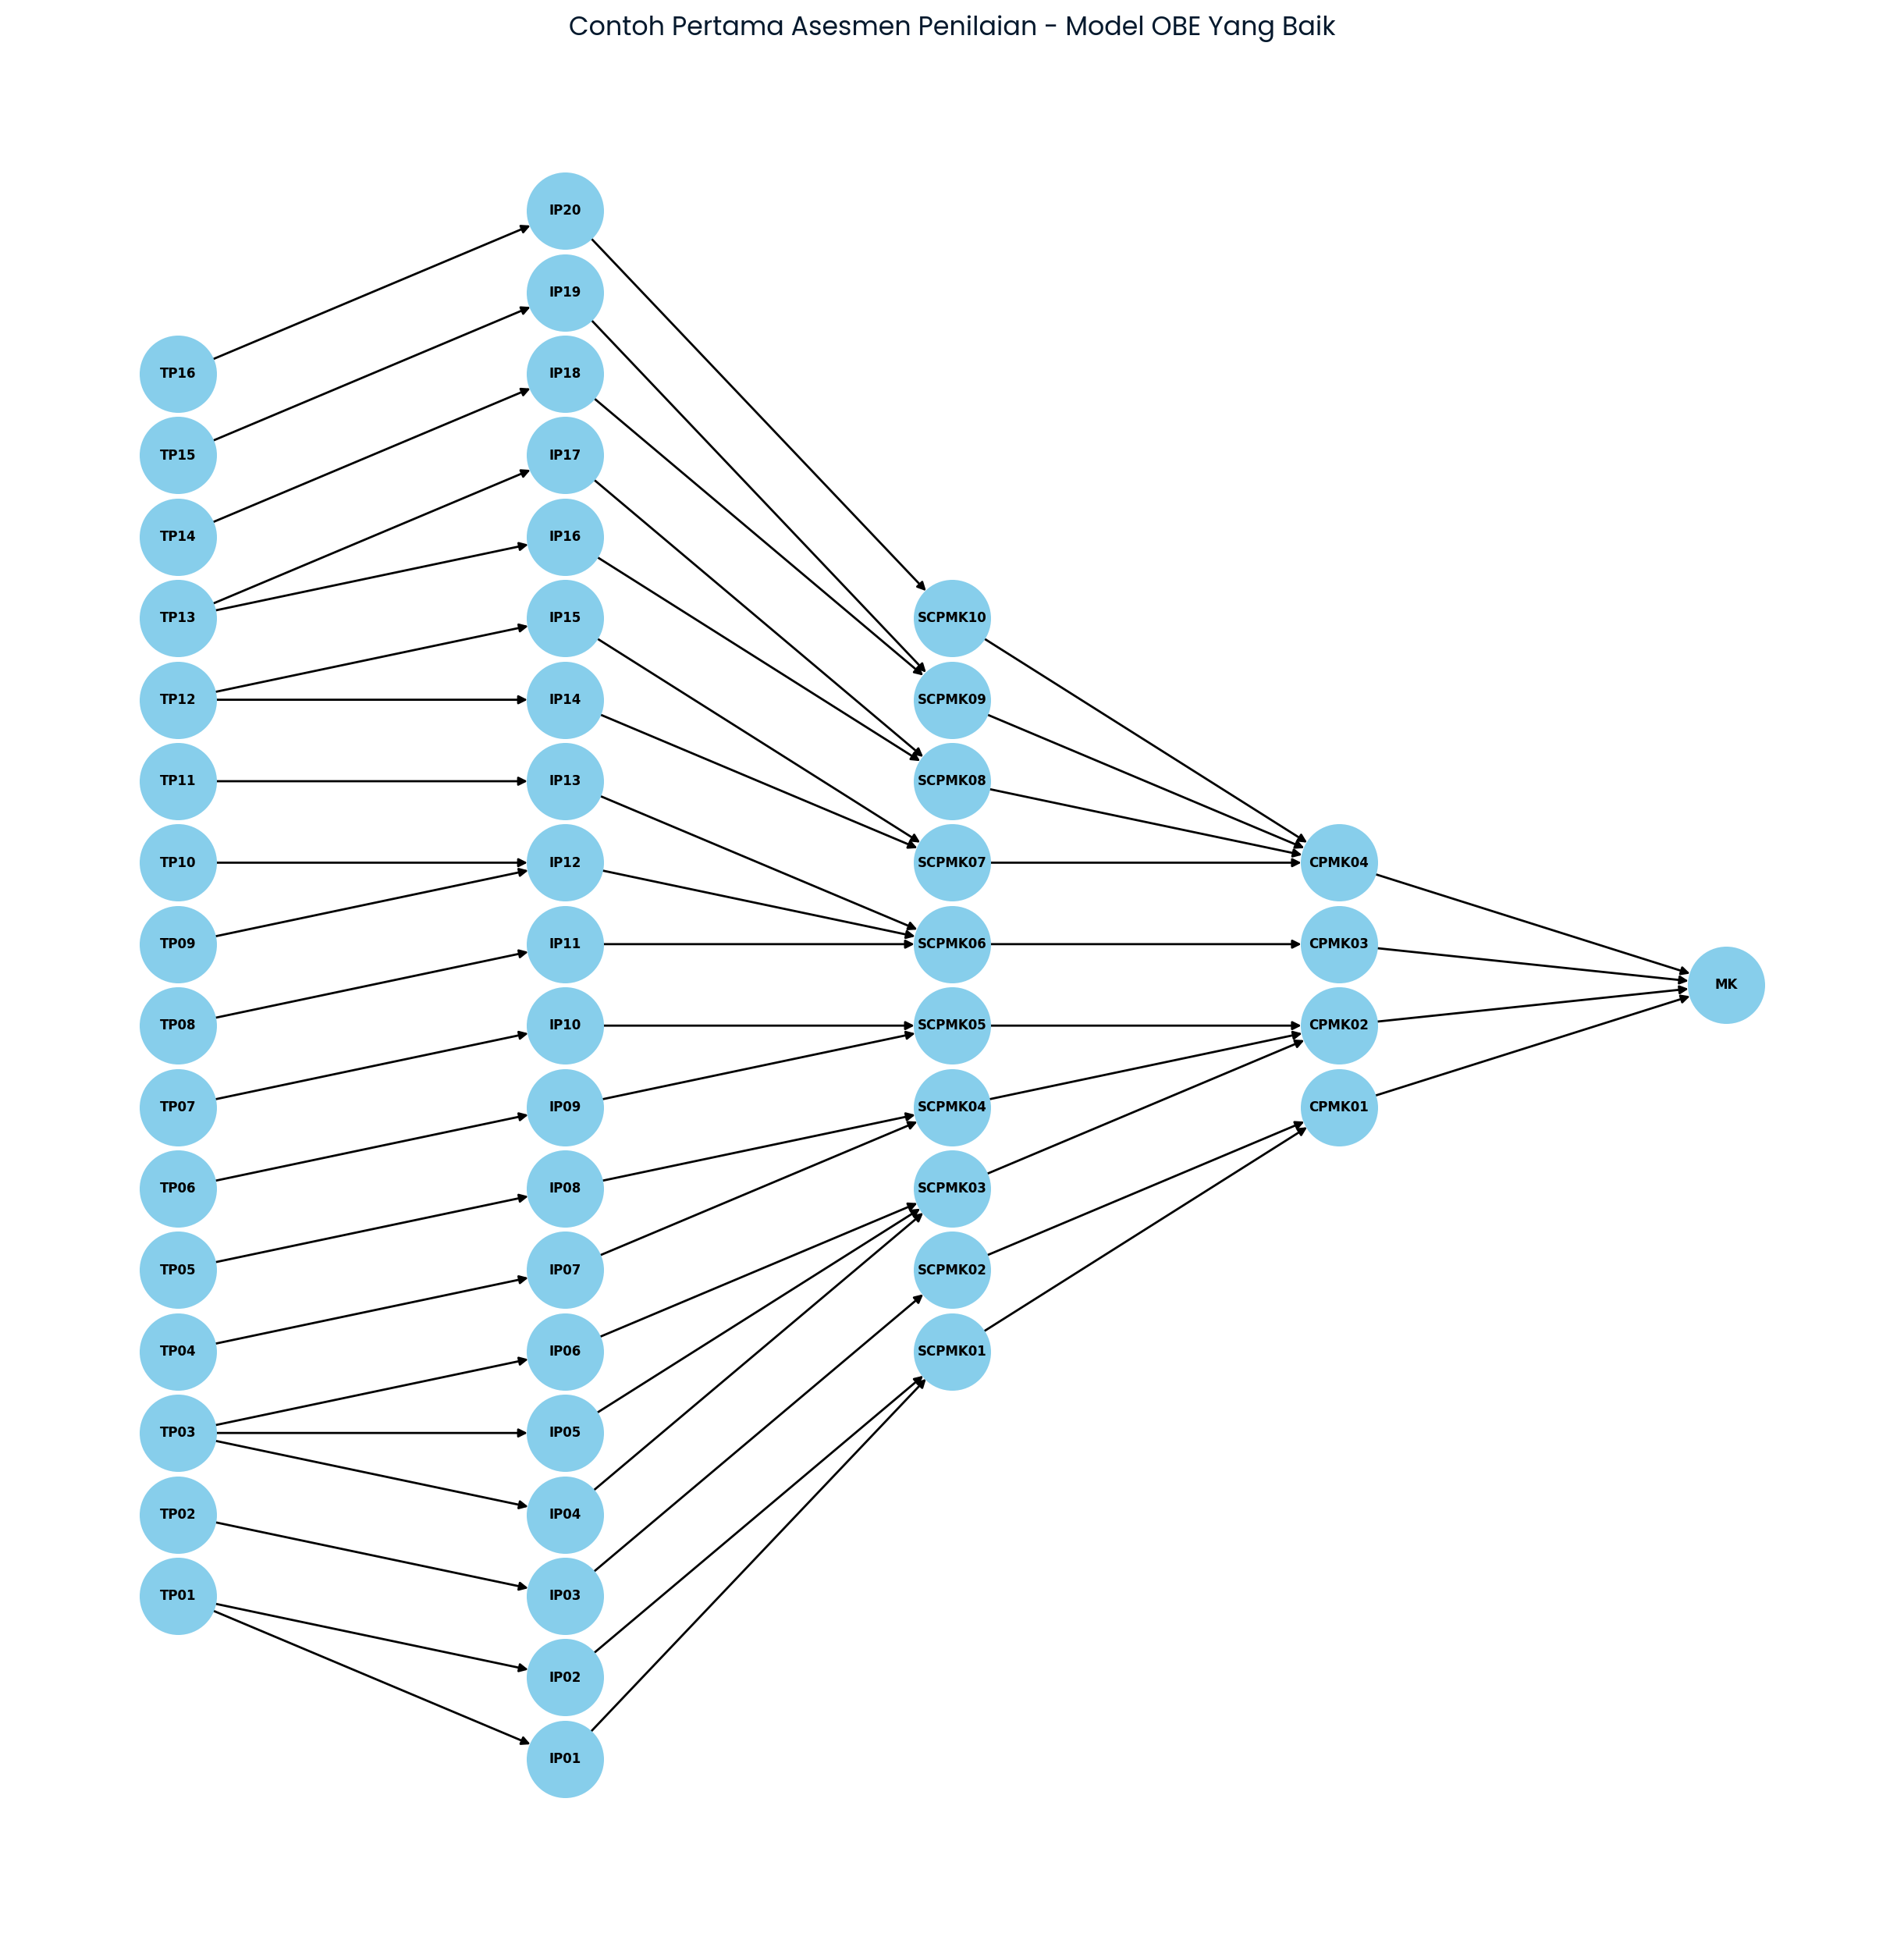

In [ ]:
nodes = {
    **{f'TP{str(i+1).zfill(2)}':     (0, 60 + i * 30) for i in range(0, 16)},
    **{f'IP{str(i+1).zfill(2)}':    (1, i * 30) for i in range(0, 20)},
    **{f'SCPMK{str(i+1).zfill(2)}': (2, 150 + i * 30) for i in range(0, 10)},
    **{f'CPMK{str(i+1).zfill(2)}':  (3, 240 + i * 30) for i in range(0, 4)},
    'MK': (4, 285)
}

edges = [
    ('TP01', 'IP01'),
    ('TP01', 'IP02'),
    ('TP02', 'IP03'),
    ('TP03', 'IP04'),
    ('TP03', 'IP05'),
    ('TP03', 'IP06'),
    ('TP04', 'IP07'),
    ('TP05', 'IP08'),
    ('TP06', 'IP09'),
    ('TP07', 'IP10'),
    ('TP08', 'IP11'),
    ('TP09', 'IP12'),
    ('TP10', 'IP12'),
    ('TP11', 'IP13'),
    ('TP12', 'IP14'),
    ('TP12', 'IP15'),
    ('TP13', 'IP16'),
    ('TP13', 'IP17'),
    ('TP14', 'IP18'),
    ('TP15', 'IP19'),
    ('TP16', 'IP20'),

    ('IP01', 'SCPMK01'),
    ('IP02', 'SCPMK01'),
    ('IP03', 'SCPMK02'),
    ('IP04', 'SCPMK03'),
    ('IP05', 'SCPMK03'),
    ('IP06', 'SCPMK03'),
    ('IP07', 'SCPMK04'),
    ('IP08', 'SCPMK04'),
    ('IP09', 'SCPMK05'),
    ('IP10', 'SCPMK05'),
    ('IP11', 'SCPMK06'),
    ('IP12', 'SCPMK06'),
    ('IP13', 'SCPMK06'),
    ('IP14', 'SCPMK07'),
    ('IP15', 'SCPMK07'),
    ('IP16', 'SCPMK08'),
    ('IP17', 'SCPMK08'),
    ('IP18', 'SCPMK09'),
    ('IP19', 'SCPMK09'),
    ('IP20', 'SCPMK10'),

    ('SCPMK01', 'CPMK01'),
    ('SCPMK02', 'CPMK01'),
    ('SCPMK03', 'CPMK02'),
    ('SCPMK04', 'CPMK02'),
    ('SCPMK05', 'CPMK02'),
    ('SCPMK06', 'CPMK03'),
    ('SCPMK07', 'CPMK04'),
    ('SCPMK08', 'CPMK04'),
    ('SCPMK09', 'CPMK04'),
    ('SCPMK10', 'CPMK04'),

    ('CPMK01','MK'),
    ('CPMK02','MK'),
    ('CPMK03','MK'),
    ('CPMK04','MK'),
]

G = nx.DiGraph()
G.add_nodes_from(nodes.keys())
G.add_edges_from(edges)

plt.figure(figsize=(12, 12))
nx.draw(G, pos=nodes, with_labels=True, node_size=1200, node_color="skyblue", font_size=6, font_weight="bold", arrowsize=8)
plt.title("Contoh Pertama Asesmen Penilaian - Model OBE Yang Baik")
plt.show()

#### Contoh Kedua - Model Blok

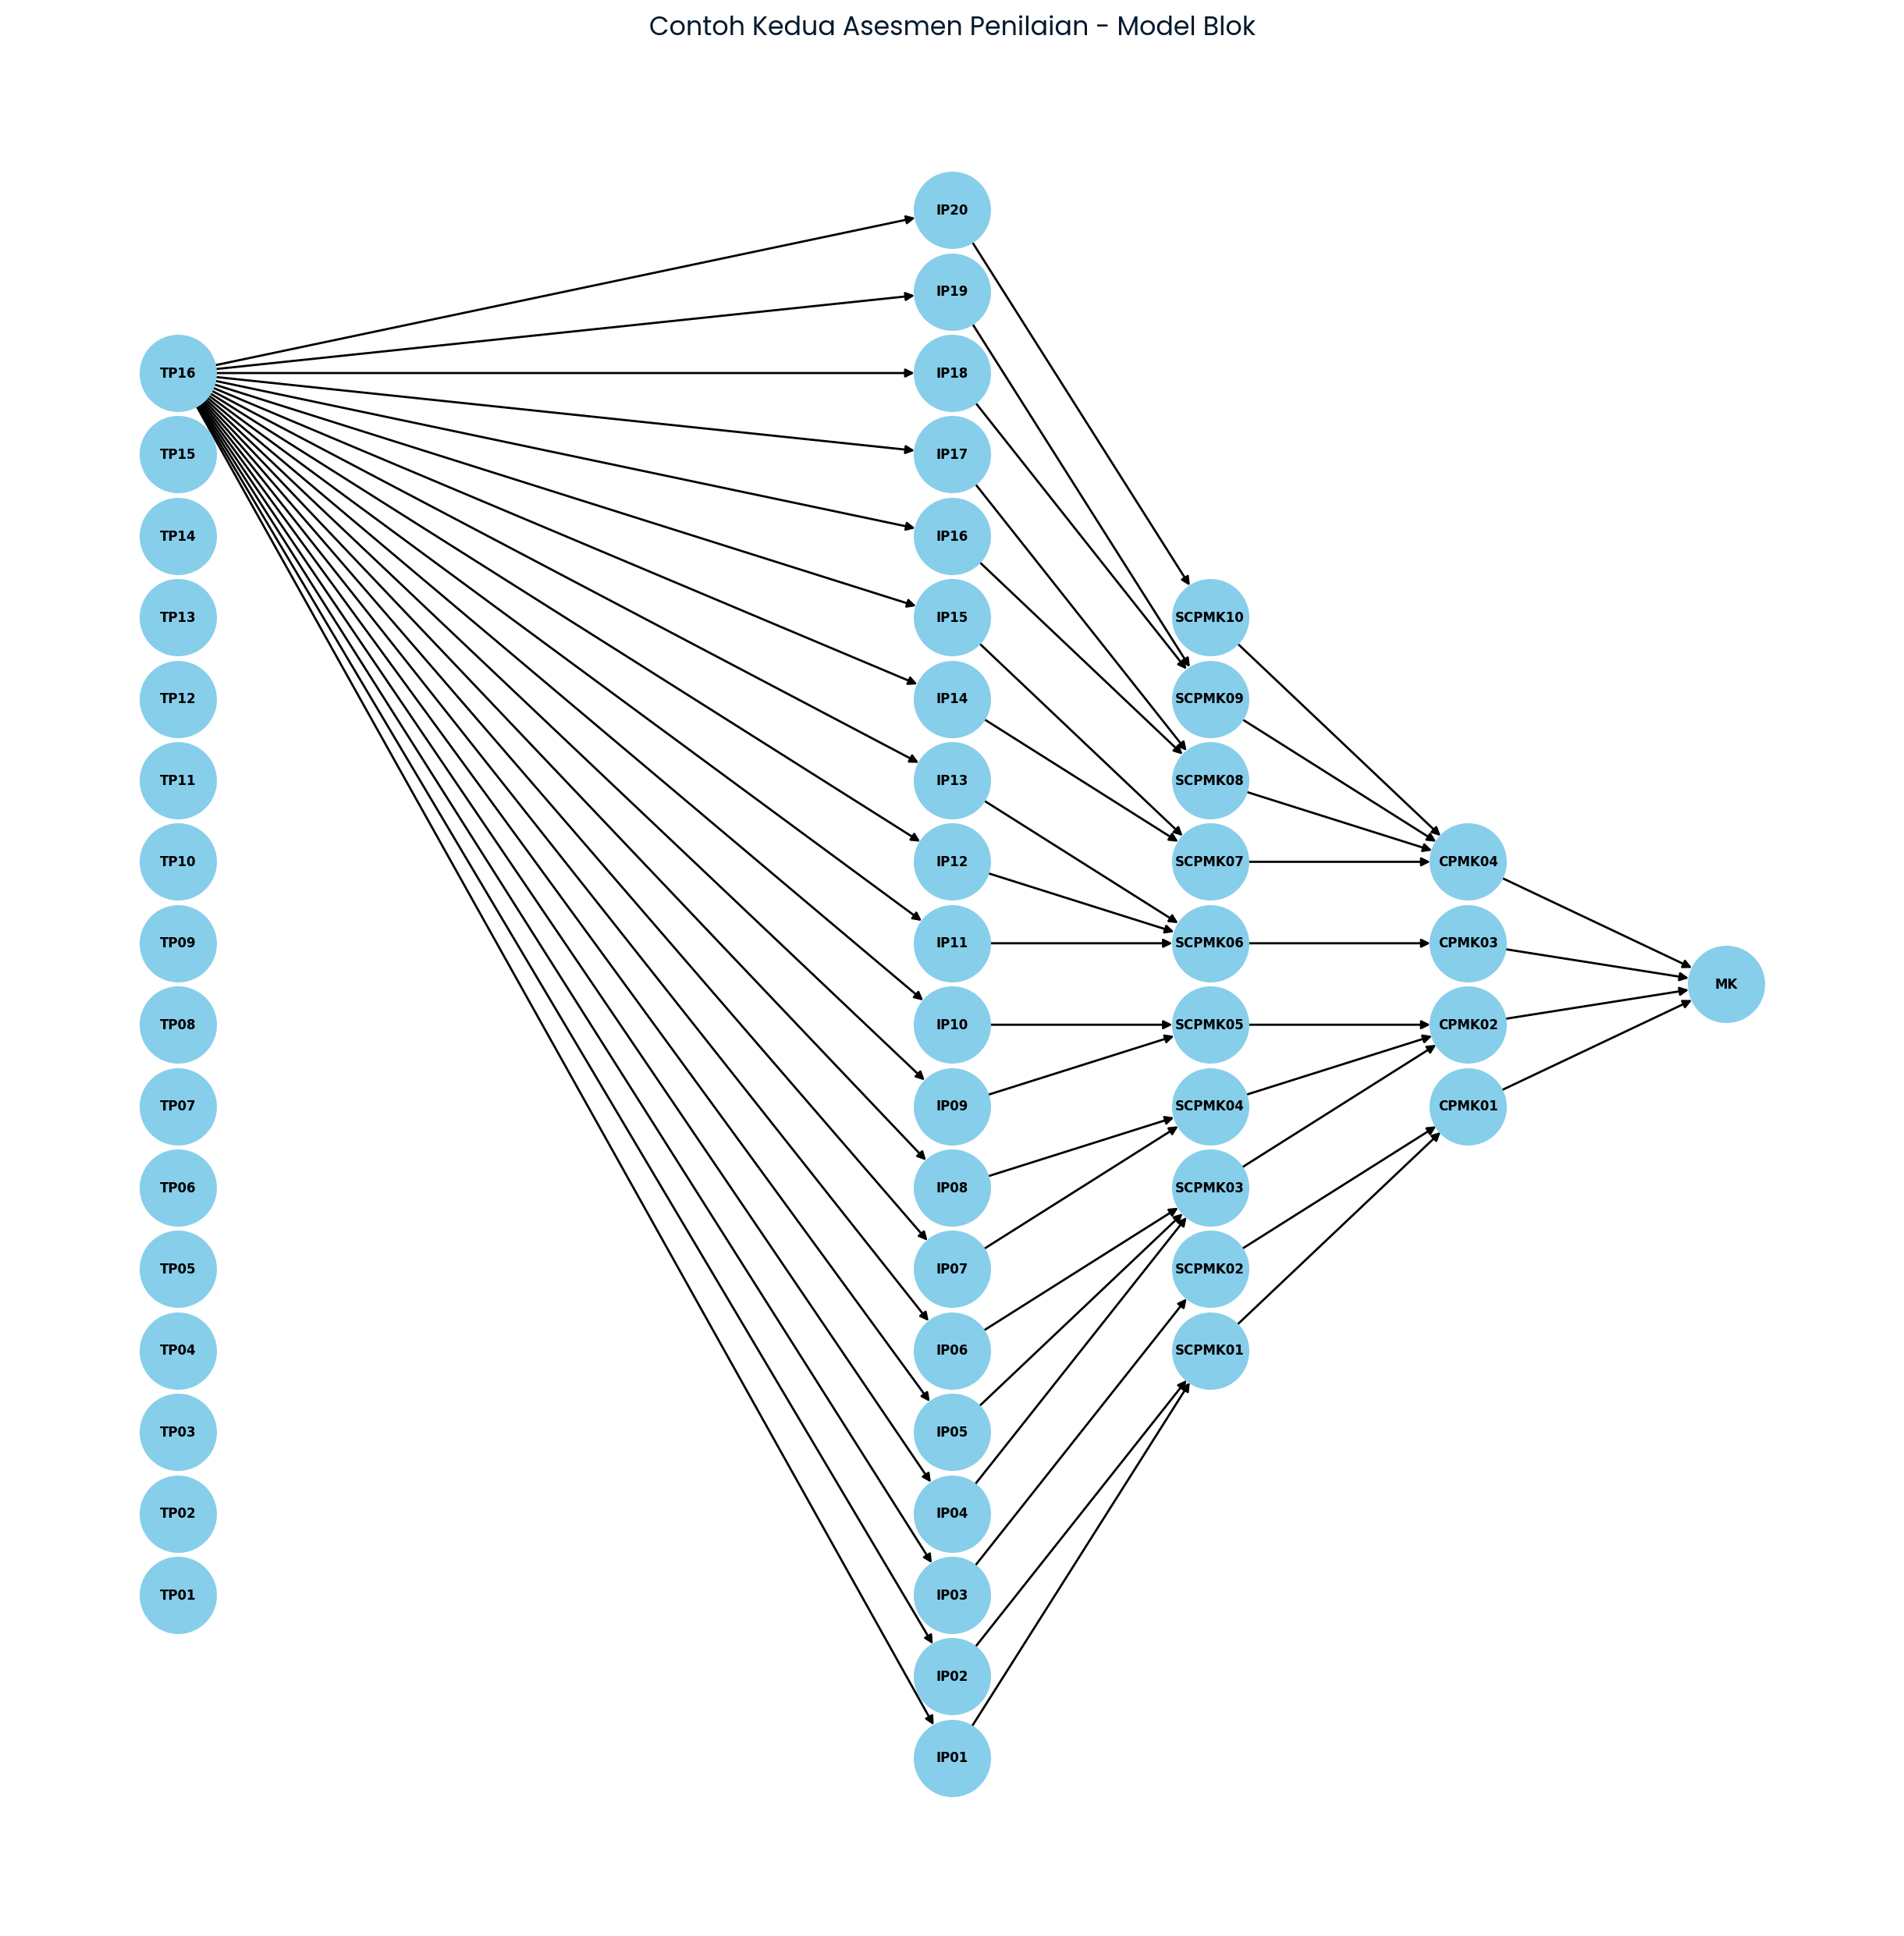

In [ ]:
nodes = {
    **{f'TP{str(i+1).zfill(2)}':     (0, 60 + i * 30) for i in range(0, 16)},
    **{f'IP{str(i+1).zfill(2)}':    (3, i * 30) for i in range(0, 20)},
    **{f'SCPMK{str(i+1).zfill(2)}': (4, 150 + i * 30) for i in range(0, 10)},
    **{f'CPMK{str(i+1).zfill(2)}':  (5, 240 + i * 30) for i in range(0, 4)},
    'MK': (6, 285)
}

edges = [
    ('TP16', 'IP01'),
    ('TP16', 'IP02'),
    ('TP16', 'IP03'),
    ('TP16', 'IP04'),
    ('TP16', 'IP05'),
    ('TP16', 'IP06'),
    ('TP16', 'IP07'),
    ('TP16', 'IP08'),
    ('TP16', 'IP09'),
    ('TP16', 'IP10'),
    ('TP16', 'IP11'),
    ('TP16', 'IP12'),
    ('TP16', 'IP12'),
    ('TP16', 'IP13'),
    ('TP16', 'IP14'),
    ('TP16', 'IP15'),
    ('TP16', 'IP16'),
    ('TP16', 'IP17'),
    ('TP16', 'IP18'),
    ('TP16', 'IP19'),
    ('TP16', 'IP20'),

    ('IP01', 'SCPMK01'),
    ('IP02', 'SCPMK01'),
    ('IP03', 'SCPMK02'),
    ('IP04', 'SCPMK03'),
    ('IP05', 'SCPMK03'),
    ('IP06', 'SCPMK03'),
    ('IP07', 'SCPMK04'),
    ('IP08', 'SCPMK04'),
    ('IP09', 'SCPMK05'),
    ('IP10', 'SCPMK05'),
    ('IP11', 'SCPMK06'),
    ('IP12', 'SCPMK06'),
    ('IP13', 'SCPMK06'),
    ('IP14', 'SCPMK07'),
    ('IP15', 'SCPMK07'),
    ('IP16', 'SCPMK08'),
    ('IP17', 'SCPMK08'),
    ('IP18', 'SCPMK09'),
    ('IP19', 'SCPMK09'),
    ('IP20', 'SCPMK10'),

    ('SCPMK01', 'CPMK01'),
    ('SCPMK02', 'CPMK01'),
    ('SCPMK03', 'CPMK02'),
    ('SCPMK04', 'CPMK02'),
    ('SCPMK05', 'CPMK02'),
    ('SCPMK06', 'CPMK03'),
    ('SCPMK07', 'CPMK04'),
    ('SCPMK08', 'CPMK04'),
    ('SCPMK09', 'CPMK04'),
    ('SCPMK10', 'CPMK04'),

    ('CPMK01','MK'),
    ('CPMK02','MK'),
    ('CPMK03','MK'),
    ('CPMK04','MK'),
]

G = nx.DiGraph()
G.add_nodes_from(nodes.keys())
G.add_edges_from(edges)

plt.figure(figsize=(12, 12))
nx.draw(G, pos=nodes, with_labels=True, node_size=1200, node_color="skyblue", font_size=6, font_weight="bold", arrowsize=8)
plt.title("Contoh Kedua Asesmen Penilaian - Model Blok")
plt.show()

#### Contoh Ketiga - Model UTS UAS

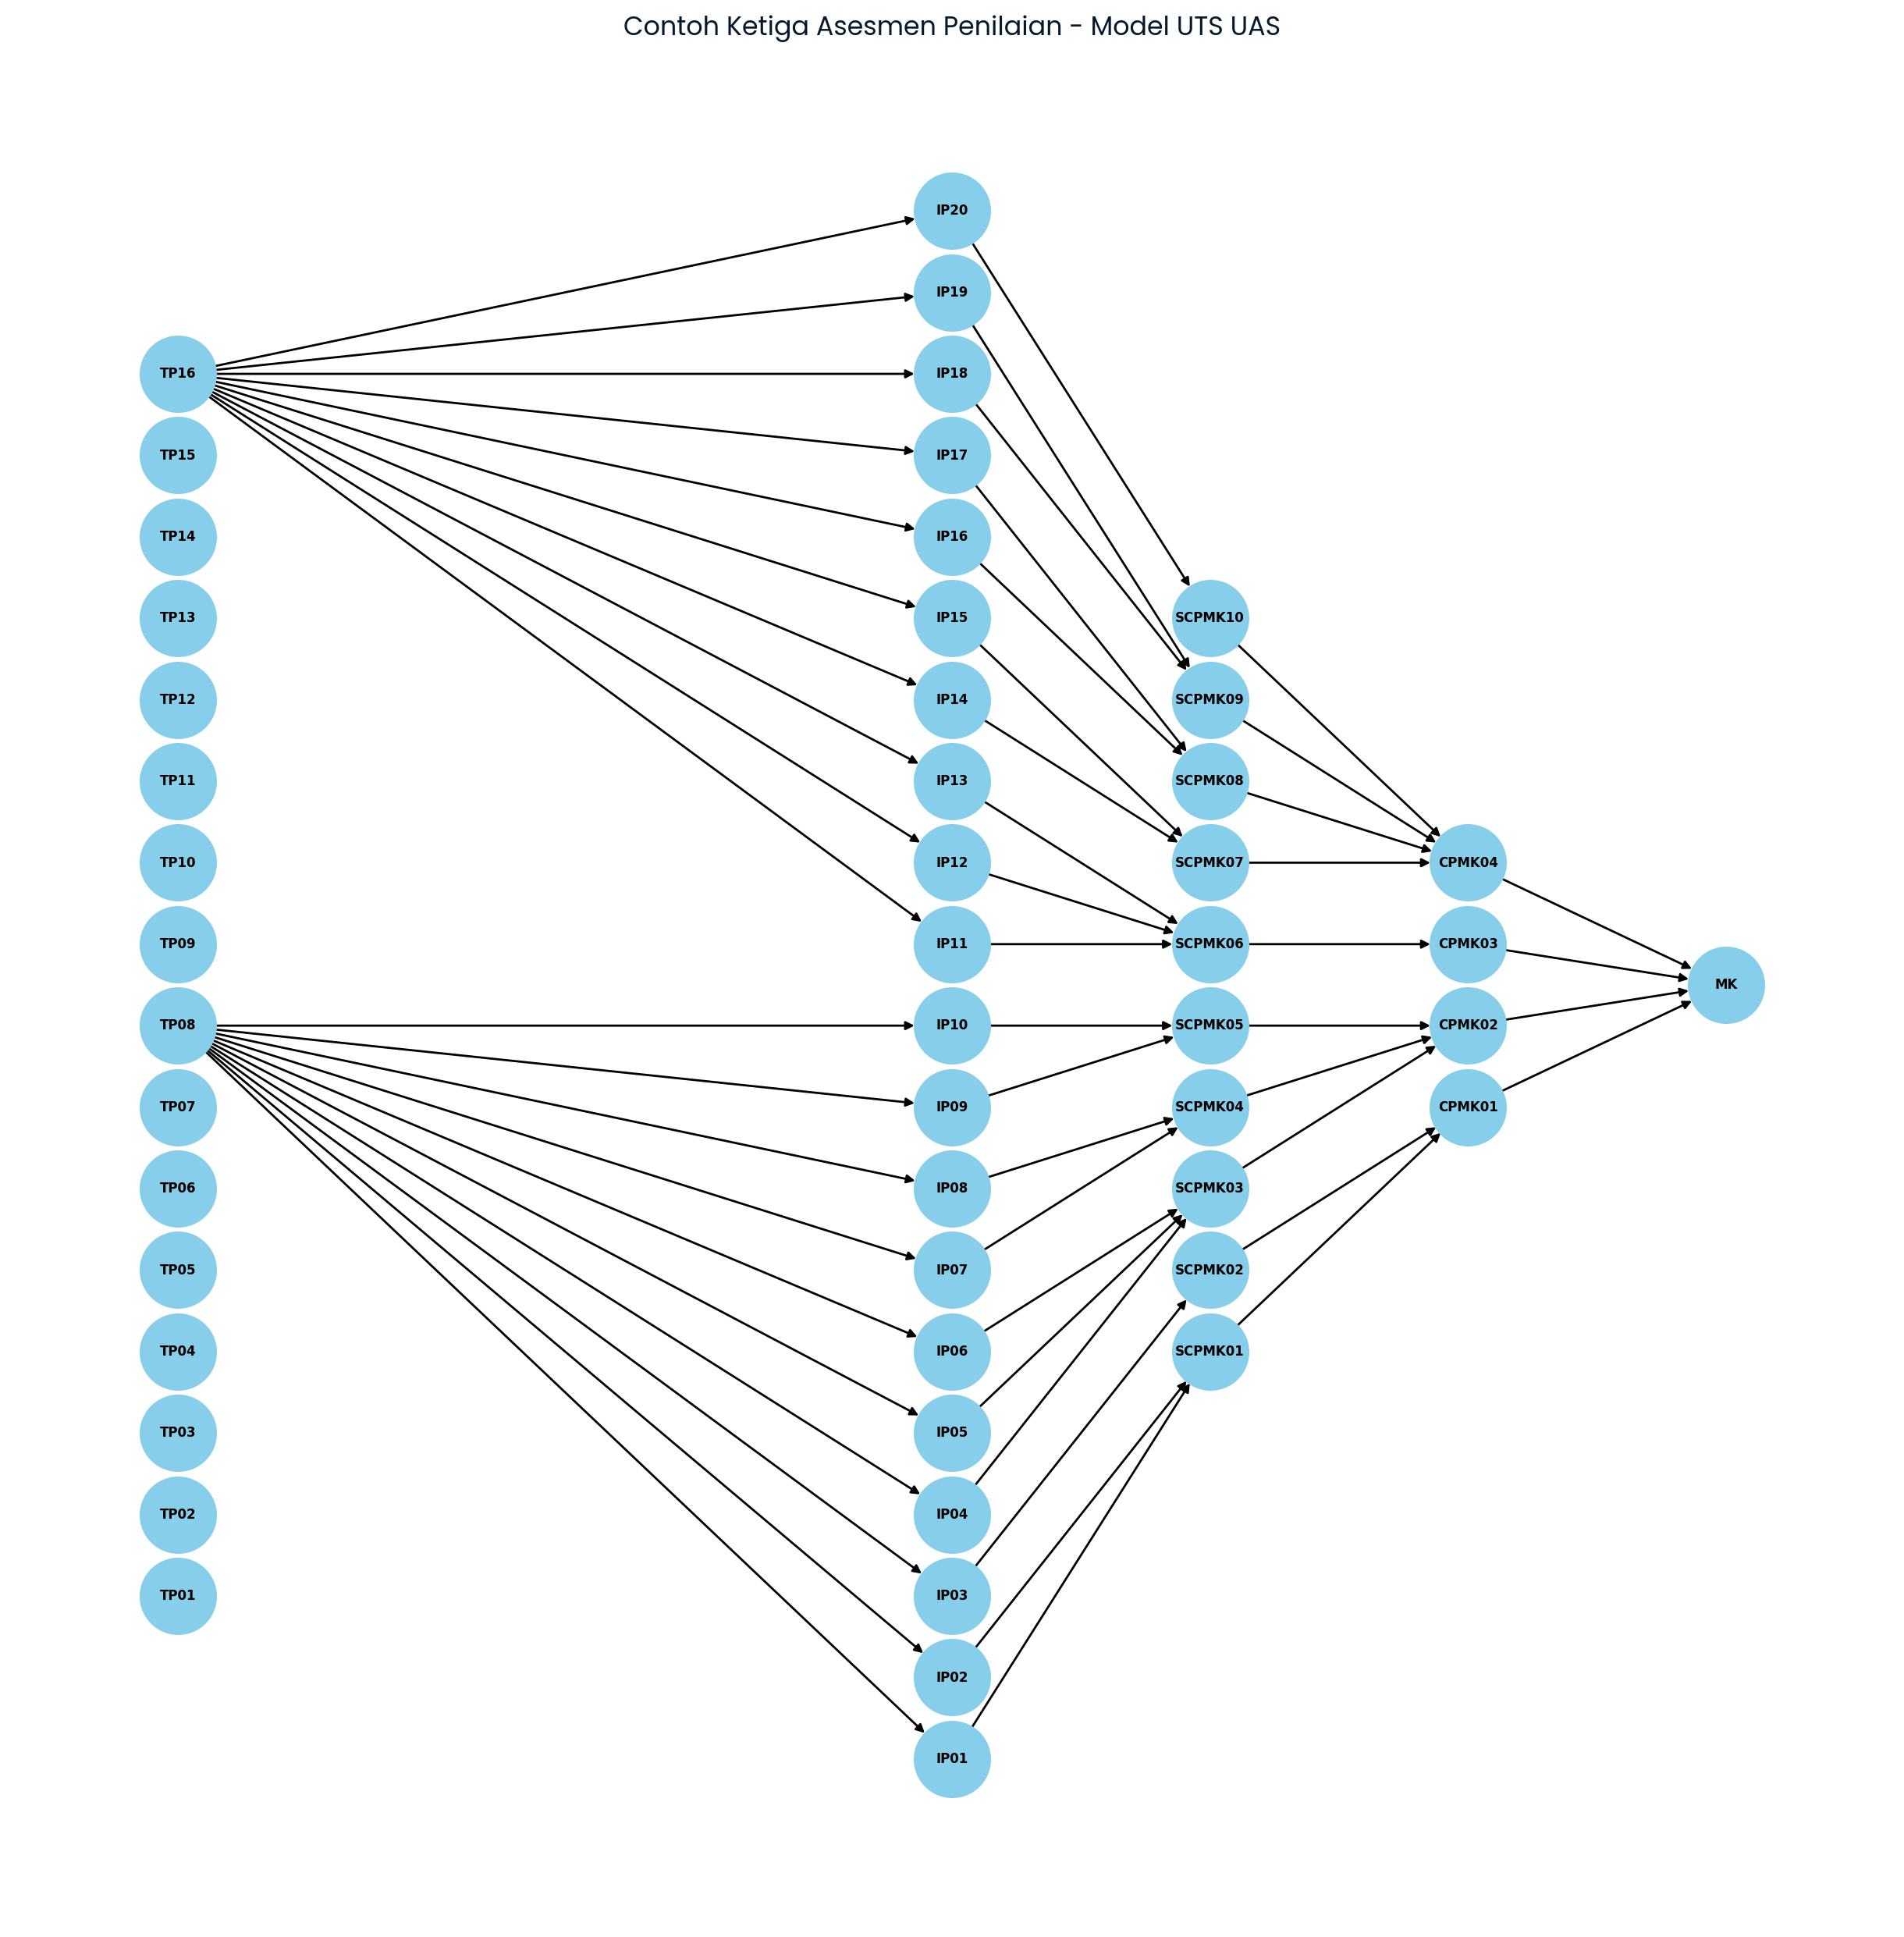

In [ ]:
nodes = {
    **{f'TP{str(i+1).zfill(2)}':     (0, 60 + i * 30) for i in range(0, 16)},
    **{f'IP{str(i+1).zfill(2)}':    (3, i * 30) for i in range(0, 20)},
    **{f'SCPMK{str(i+1).zfill(2)}': (4, 150 + i * 30) for i in range(0, 10)},
    **{f'CPMK{str(i+1).zfill(2)}':  (5, 240 + i * 30) for i in range(0, 4)},
    'MK': (6, 285)
}

edges = [
    ('TP08', 'IP01'),
    ('TP08', 'IP02'),
    ('TP08', 'IP03'),
    ('TP08', 'IP04'),
    ('TP08', 'IP05'),
    ('TP08', 'IP06'),
    ('TP08', 'IP07'),
    ('TP08', 'IP08'),
    ('TP08', 'IP09'),
    ('TP08', 'IP10'),
    ('TP16', 'IP11'),
    ('TP16', 'IP12'),
    ('TP16', 'IP12'),
    ('TP16', 'IP13'),
    ('TP16', 'IP14'),
    ('TP16', 'IP15'),
    ('TP16', 'IP16'),
    ('TP16', 'IP17'),
    ('TP16', 'IP18'),
    ('TP16', 'IP19'),
    ('TP16', 'IP20'),

    ('IP01', 'SCPMK01'),
    ('IP02', 'SCPMK01'),
    ('IP03', 'SCPMK02'),
    ('IP04', 'SCPMK03'),
    ('IP05', 'SCPMK03'),
    ('IP06', 'SCPMK03'),
    ('IP07', 'SCPMK04'),
    ('IP08', 'SCPMK04'),
    ('IP09', 'SCPMK05'),
    ('IP10', 'SCPMK05'),
    ('IP11', 'SCPMK06'),
    ('IP12', 'SCPMK06'),
    ('IP13', 'SCPMK06'),
    ('IP14', 'SCPMK07'),
    ('IP15', 'SCPMK07'),
    ('IP16', 'SCPMK08'),
    ('IP17', 'SCPMK08'),
    ('IP18', 'SCPMK09'),
    ('IP19', 'SCPMK09'),
    ('IP20', 'SCPMK10'),

    ('SCPMK01', 'CPMK01'),
    ('SCPMK02', 'CPMK01'),
    ('SCPMK03', 'CPMK02'),
    ('SCPMK04', 'CPMK02'),
    ('SCPMK05', 'CPMK02'),
    ('SCPMK06', 'CPMK03'),
    ('SCPMK07', 'CPMK04'),
    ('SCPMK08', 'CPMK04'),
    ('SCPMK09', 'CPMK04'),
    ('SCPMK10', 'CPMK04'),

    ('CPMK01','MK'),
    ('CPMK02','MK'),
    ('CPMK03','MK'),
    ('CPMK04','MK'),
]

G = nx.DiGraph()
G.add_nodes_from(nodes.keys())
G.add_edges_from(edges)

plt.figure(figsize=(12, 12))
nx.draw(G, pos=nodes, with_labels=True, node_size=1200, node_color="skyblue", font_size=6, font_weight="bold", arrowsize=8)
plt.title("Contoh Ketiga Asesmen Penilaian - Model UTS UAS")
plt.show()

#### Contoh Keempat - Model Syarat Lulus

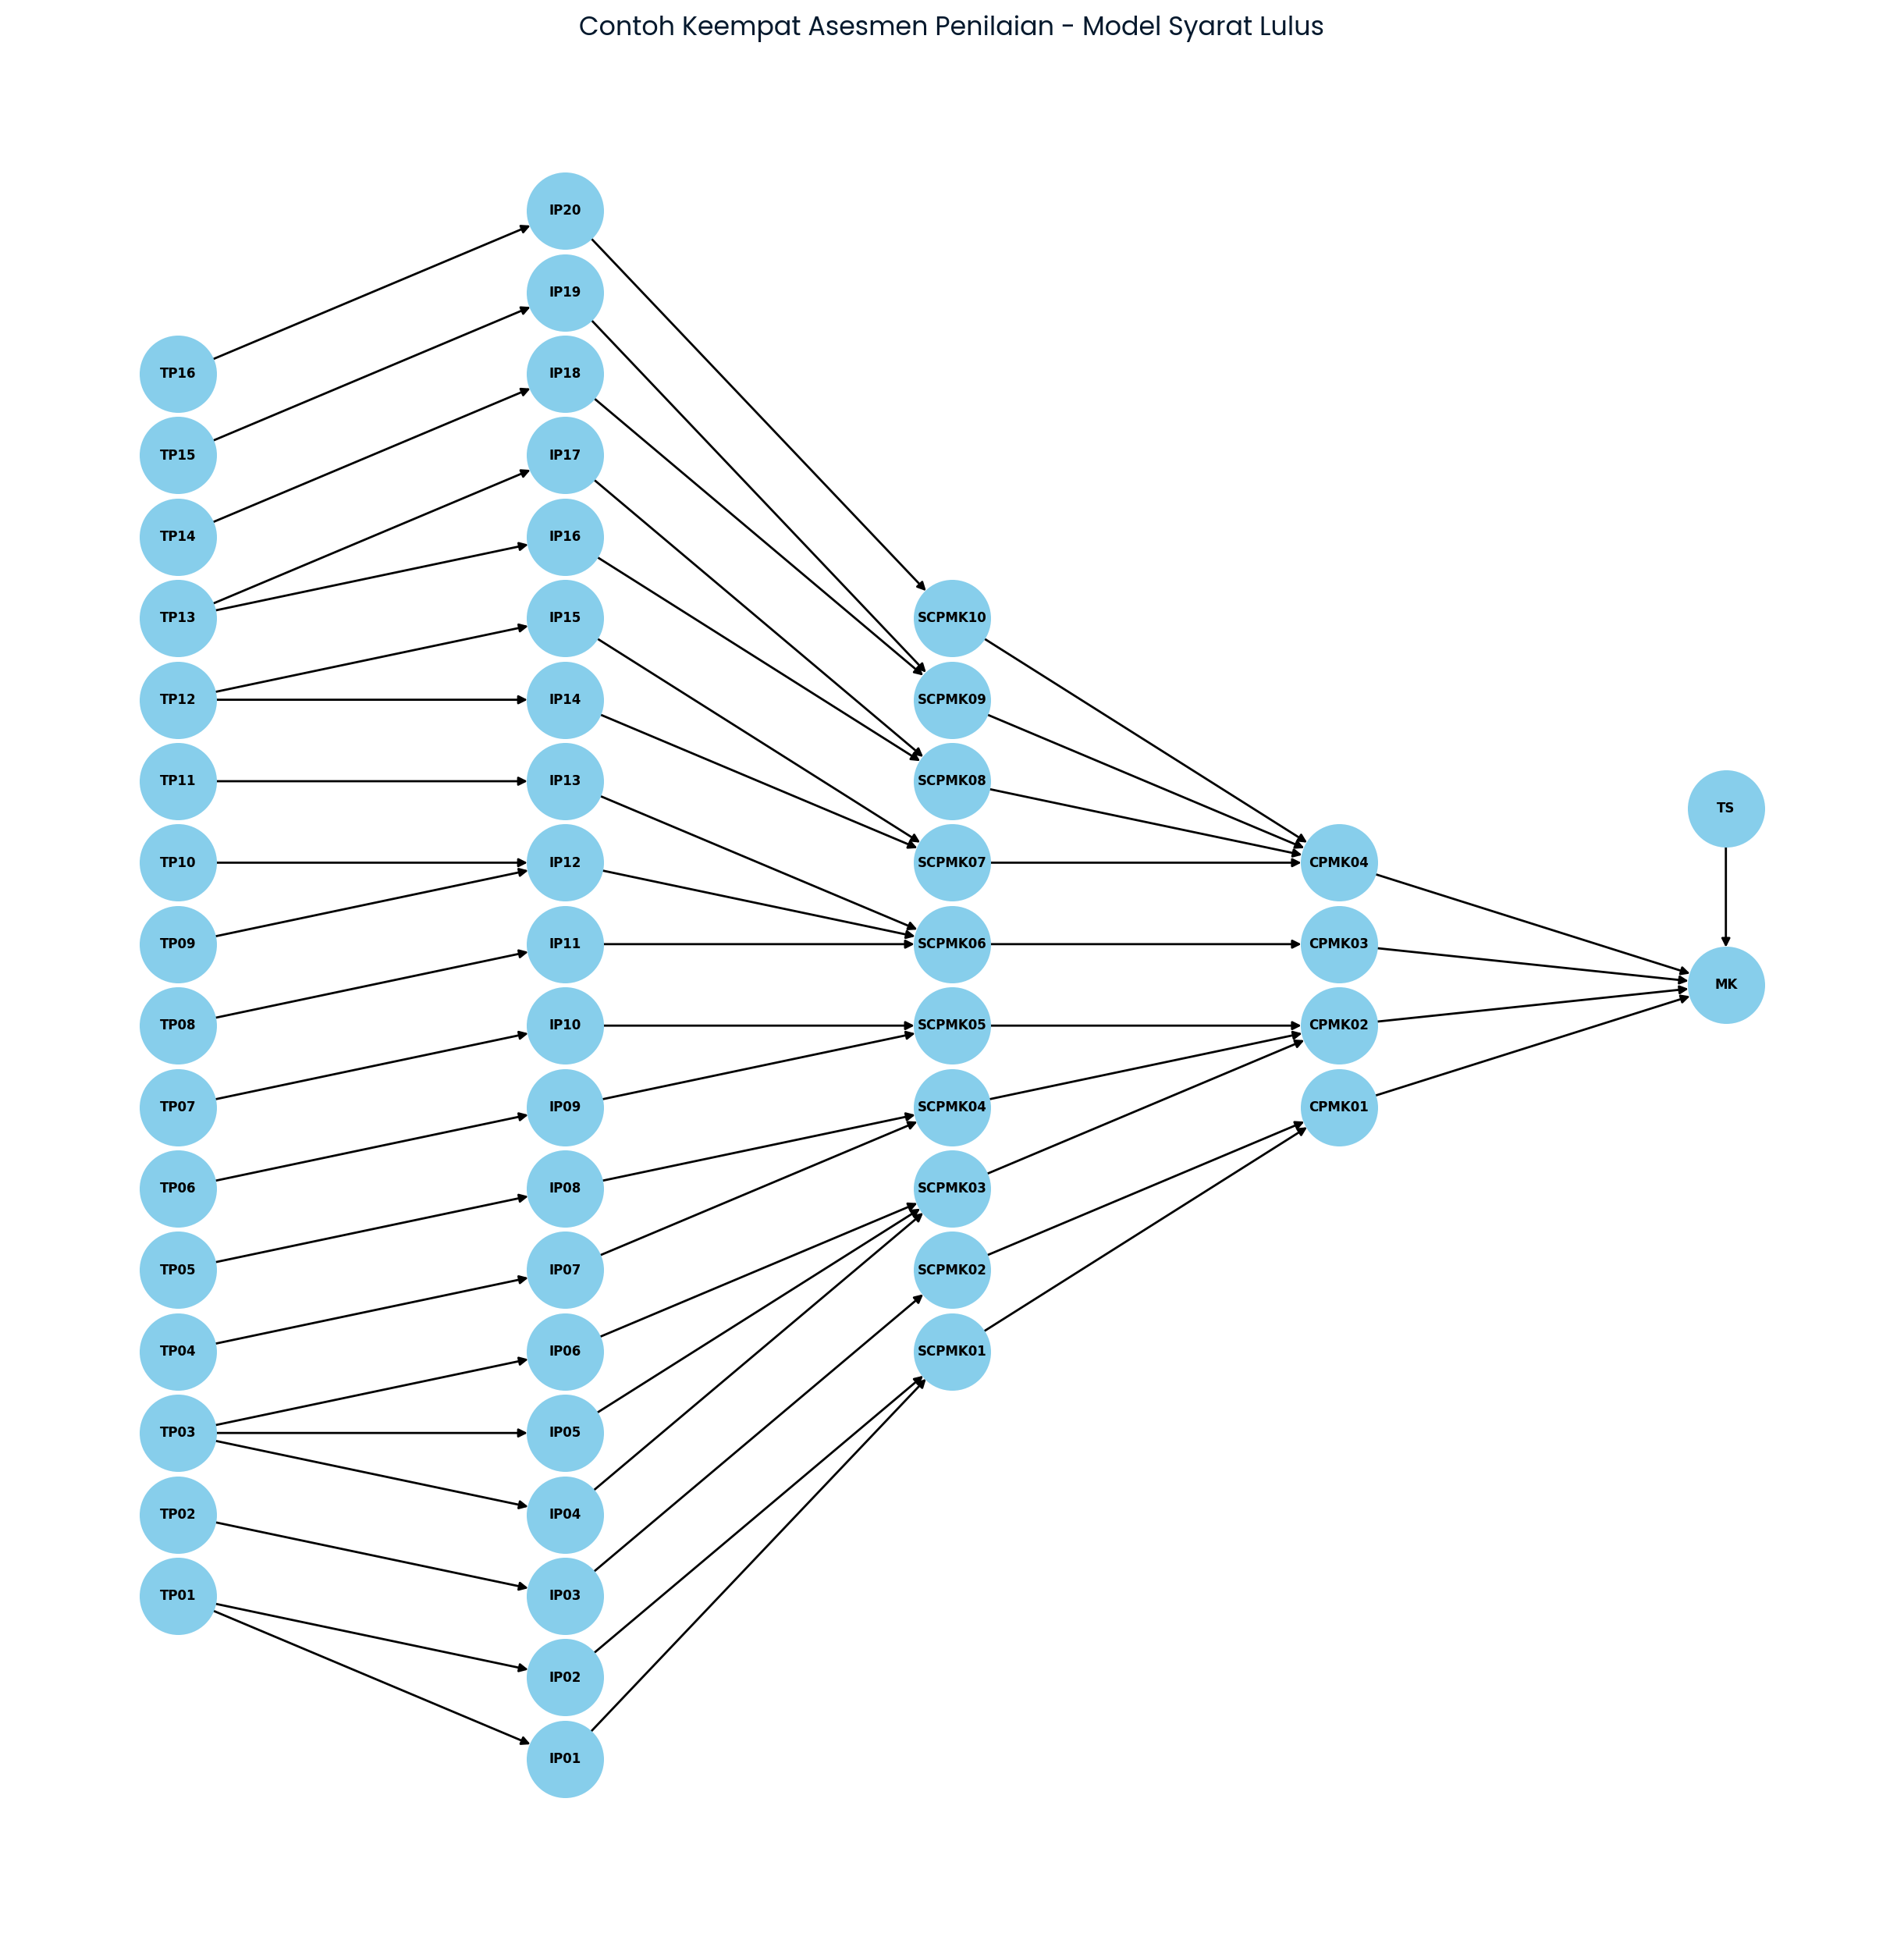

In [ ]:
nodes = {
    **{f'TP{str(i+1).zfill(2)}':     (0, 60 + i * 30) for i in range(0, 16)},
    **{f'IP{str(i+1).zfill(2)}':    (1, i * 30) for i in range(0, 20)},
    **{f'SCPMK{str(i+1).zfill(2)}': (2, 150 + i * 30) for i in range(0, 10)},
    **{f'CPMK{str(i+1).zfill(2)}':  (3, 240 + i * 30) for i in range(0, 4)},
    'MK': (4, 285),
    'TS': (4, 350)
}

edges = [
    ('TP01', 'IP01'),
    ('TP01', 'IP02'),
    ('TP02', 'IP03'),
    ('TP03', 'IP04'),
    ('TP03', 'IP05'),
    ('TP03', 'IP06'),
    ('TP04', 'IP07'),
    ('TP05', 'IP08'),
    ('TP06', 'IP09'),
    ('TP07', 'IP10'),
    ('TP08', 'IP11'),
    ('TP09', 'IP12'),
    ('TP10', 'IP12'),
    ('TP11', 'IP13'),
    ('TP12', 'IP14'),
    ('TP12', 'IP15'),
    ('TP13', 'IP16'),
    ('TP13', 'IP17'),
    ('TP14', 'IP18'),
    ('TP15', 'IP19'),
    ('TP16', 'IP20'),

    ('IP01', 'SCPMK01'),
    ('IP02', 'SCPMK01'),
    ('IP03', 'SCPMK02'),
    ('IP04', 'SCPMK03'),
    ('IP05', 'SCPMK03'),
    ('IP06', 'SCPMK03'),
    ('IP07', 'SCPMK04'),
    ('IP08', 'SCPMK04'),
    ('IP09', 'SCPMK05'),
    ('IP10', 'SCPMK05'),
    ('IP11', 'SCPMK06'),
    ('IP12', 'SCPMK06'),
    ('IP13', 'SCPMK06'),
    ('IP14', 'SCPMK07'),
    ('IP15', 'SCPMK07'),
    ('IP16', 'SCPMK08'),
    ('IP17', 'SCPMK08'),
    ('IP18', 'SCPMK09'),
    ('IP19', 'SCPMK09'),
    ('IP20', 'SCPMK10'),

    ('SCPMK01', 'CPMK01'),
    ('SCPMK02', 'CPMK01'),
    ('SCPMK03', 'CPMK02'),
    ('SCPMK04', 'CPMK02'),
    ('SCPMK05', 'CPMK02'),
    ('SCPMK06', 'CPMK03'),
    ('SCPMK07', 'CPMK04'),
    ('SCPMK08', 'CPMK04'),
    ('SCPMK09', 'CPMK04'),
    ('SCPMK10', 'CPMK04'),

    ('CPMK01','MK'),
    ('CPMK02','MK'),
    ('CPMK03','MK'),
    ('CPMK04','MK'),
    ('TS','MK')
]

G = nx.DiGraph()
G.add_nodes_from(nodes.keys())
G.add_edges_from(edges)

plt.figure(figsize=(12, 12))
nx.draw(G, pos=nodes, with_labels=True, node_size=1200, node_color="skyblue", font_size=6, font_weight="bold", arrowsize=8)
plt.title("Contoh Keempat Asesmen Penilaian - Model Syarat Lulus")
plt.show()

### Contoh Mind Map MK Machine Learning

![mindmap-machine-learning](mindmap-machine-learning.jpg)

### Contoh Pemetaan OL, PL, dan CPL

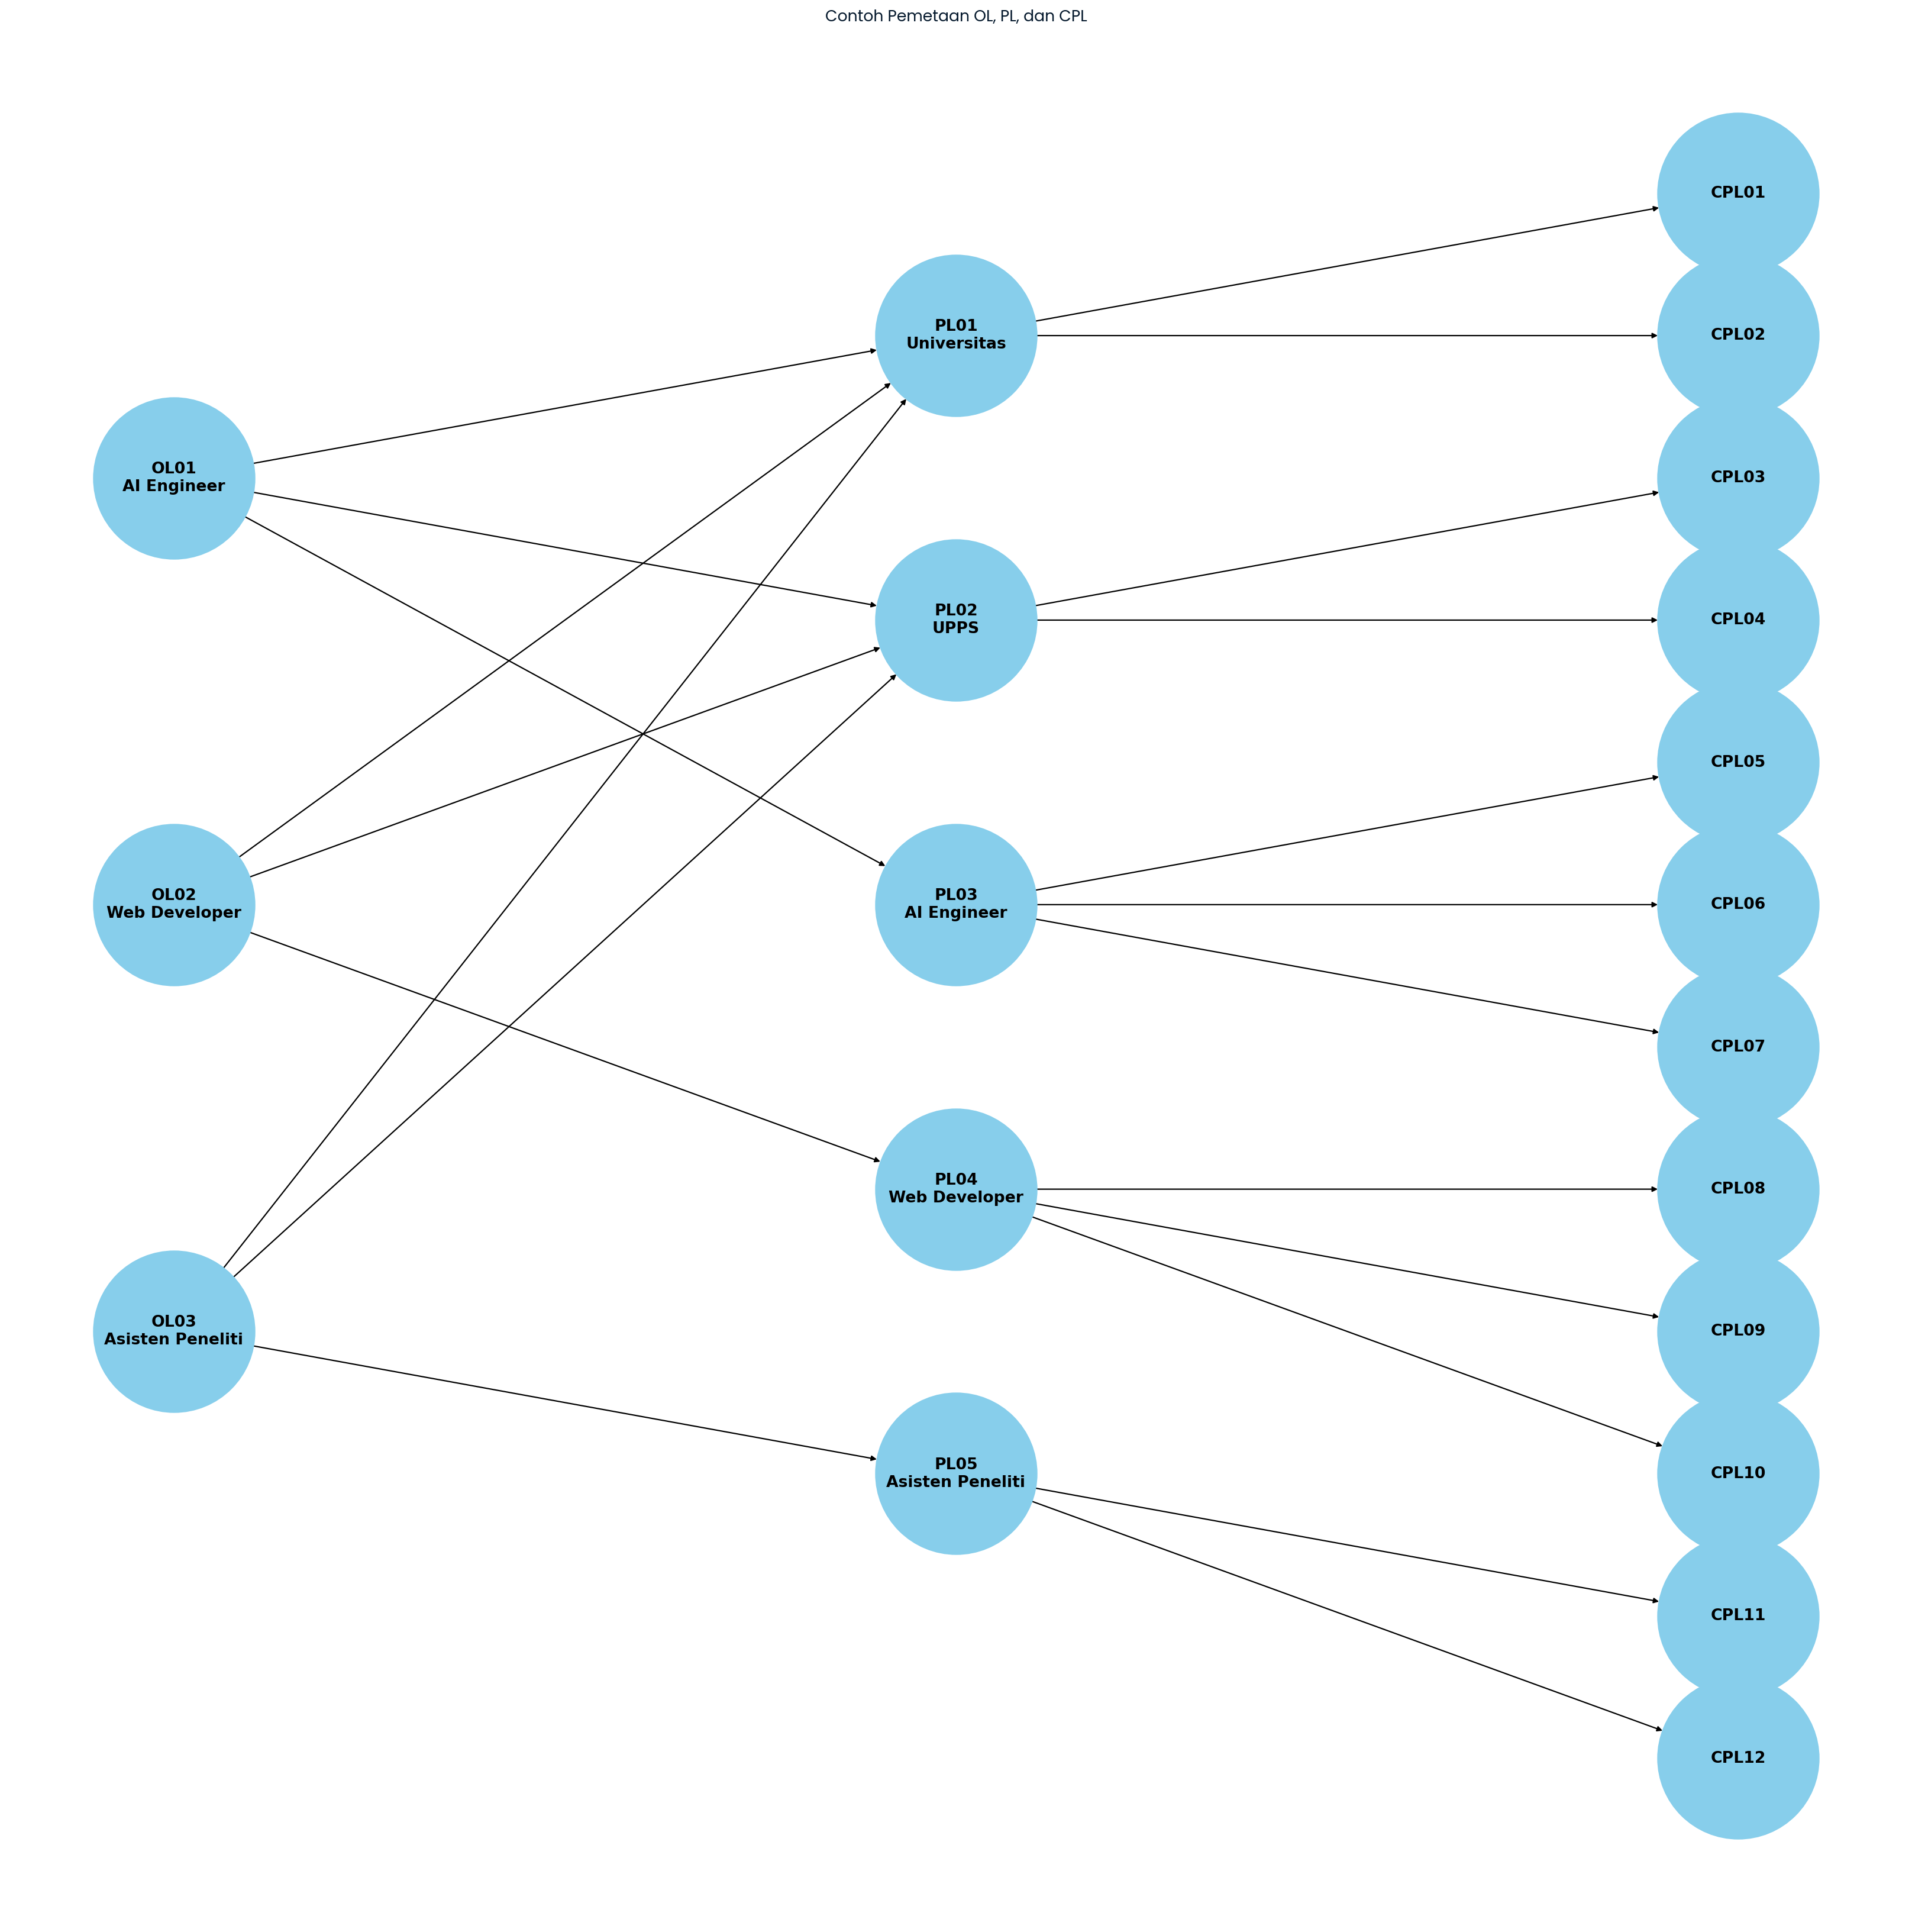

In [ ]:
nodes = {
    'OL01\nAI Engineer': (0, 9),
    'OL02\nWeb Developer': (0, 6),
    'OL03\nAsisten Peneliti': (0, 3),
    'PL01\nUniversitas': (1, 10),
    'PL02\nUPPS': (1, 8),
    'PL03\nAI Engineer': (1, 6),
    'PL04\nWeb Developer': (1, 4),
    'PL05\nAsisten Peneliti': (1, 2),
    **{f'CPL{str(i+1).zfill(2)}':     (2, 11-i) for i in range(0, 12)},
}

edges = [
    ('OL01\nAI Engineer', 'PL01\nUniversitas'),
    ('OL02\nWeb Developer', 'PL01\nUniversitas'),
    ('OL03\nAsisten Peneliti', 'PL01\nUniversitas'),
    ('OL01\nAI Engineer', 'PL02\nUPPS'),
    ('OL02\nWeb Developer', 'PL02\nUPPS'),
    ('OL03\nAsisten Peneliti', 'PL02\nUPPS'),
    ('OL01\nAI Engineer', 'PL03\nAI Engineer'),
    ('OL02\nWeb Developer', 'PL04\nWeb Developer'),
    ('OL03\nAsisten Peneliti', 'PL05\nAsisten Peneliti'),
    ('PL01\nUniversitas', 'CPL01'),
    ('PL01\nUniversitas', 'CPL02'),
    ('PL02\nUPPS', 'CPL03'),
    ('PL02\nUPPS', 'CPL04'),
    ('PL03\nAI Engineer', 'CPL05'),
    ('PL03\nAI Engineer', 'CPL06'),
    ('PL03\nAI Engineer', 'CPL07'),
    ('PL04\nWeb Developer', 'CPL08'),
    ('PL04\nWeb Developer', 'CPL09'),
    ('PL04\nWeb Developer', 'CPL10'),
    ('PL05\nAsisten Peneliti', 'CPL11'),
    ('PL05\nAsisten Peneliti', 'CPL12')
]

G = nx.DiGraph()
G.add_nodes_from(nodes.keys())
G.add_edges_from(edges)

plt.figure(figsize=(20, 20), dpi= 80)
nx.draw(G, pos=nodes, with_labels=True, node_size=15000, node_color="skyblue", font_size=12, font_weight="bold", arrowsize=8)
plt.title("Contoh Pemetaan OL, PL, dan CPL")
plt.show()